<a href="https://colab.research.google.com/github/sapirbakshiatias/ML--BANKING77/blob/main/ML_BANKING77.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Exploratory Data Analysis (EDA) and Pre-processing

## 1.1 Data Loading and Technical Setup
In this step, we load the `BANKING77` dataset from Hugging Face. We will convert it to Pandas DataFrames for easier manipulation and perform basic data integrity checks, such as looking for missing values and duplicated texts.

In [2]:
# Install a specific version of datasets to avoid remote code execution errors in Colab
!pip install -q "datasets==2.19.1" pandas numpy

import pandas as pd
from datasets import load_dataset

# Load the BANKING77 dataset
print("Loading BANKING77 dataset...")
# dataset = load_dataset("PolyAI/banking77",trust_remote_code=True)
dataset = load_dataset("mteb/banking77")
# dataset = load_dataset(
#     "parquet",
#     data_files={
#         "train": "hf://datasets/PolyAI/banking77@refs/convert/parquet/default/train/0000.parquet",
#         "test": "hf://datasets/PolyAI/banking77@refs/convert/parquet/default/test/0000.parquet"
#     }
# )

# Convert to Pandas DataFrames for easier analysis
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

# 1. Verify dataset sizes
print(f"Train set shape: {train_df.shape} (Expected: 10003 rows)")
print(f"Test set shape: {test_df.shape} (Expected: 3080 rows)")

# 2. Check for missing values (NaNs)
print("\n--- Missing Values ---")
print(f"Missing values in Train set:\n{train_df.isnull().sum()}\n")
print(f"Missing values in Test set:\n{test_df.isnull().sum()}")

# 3. Check for exact duplicates in the text
train_duplicates = train_df.duplicated(subset=['text']).sum()
test_duplicates = test_df.duplicated(subset=['text']).sum()

print("\n--- Duplicates ---")
print(f"Exact text duplicates in Train set: {train_duplicates}")
print(f"Exact text duplicates in Test set: {test_duplicates}")

# Show the first 3 rows to verify structure
print("\n--- First 3 rows of Train set ---")
train_df.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
Loading BANKING77 dataset...


Generating train split:   0%|          | 0/9993 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3076 [00:00<?, ? examples/s]

Train set shape: (9993, 3) (Expected: 10003 rows)
Test set shape: (3076, 3) (Expected: 3080 rows)

--- Missing Values ---
Missing values in Train set:
text          0
label         0
label_text    0
dtype: int64

Missing values in Test set:
text          0
label         0
label_text    0
dtype: int64

--- Duplicates ---
Exact text duplicates in Train set: 0
Exact text duplicates in Test set: 0

--- First 3 rows of Train set ---


,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival


## 1.2 Exploratory Data Analysis (EDA) on Train Set

Starting Exploratory Data Analysis on Train set...

--- Class Distribution Statistics ---
Total number of unique classes: 77
Largest class (Label ID 15): 187 samples
Smallest class (Label ID 23): 35 samples
Average samples per class: 129.78


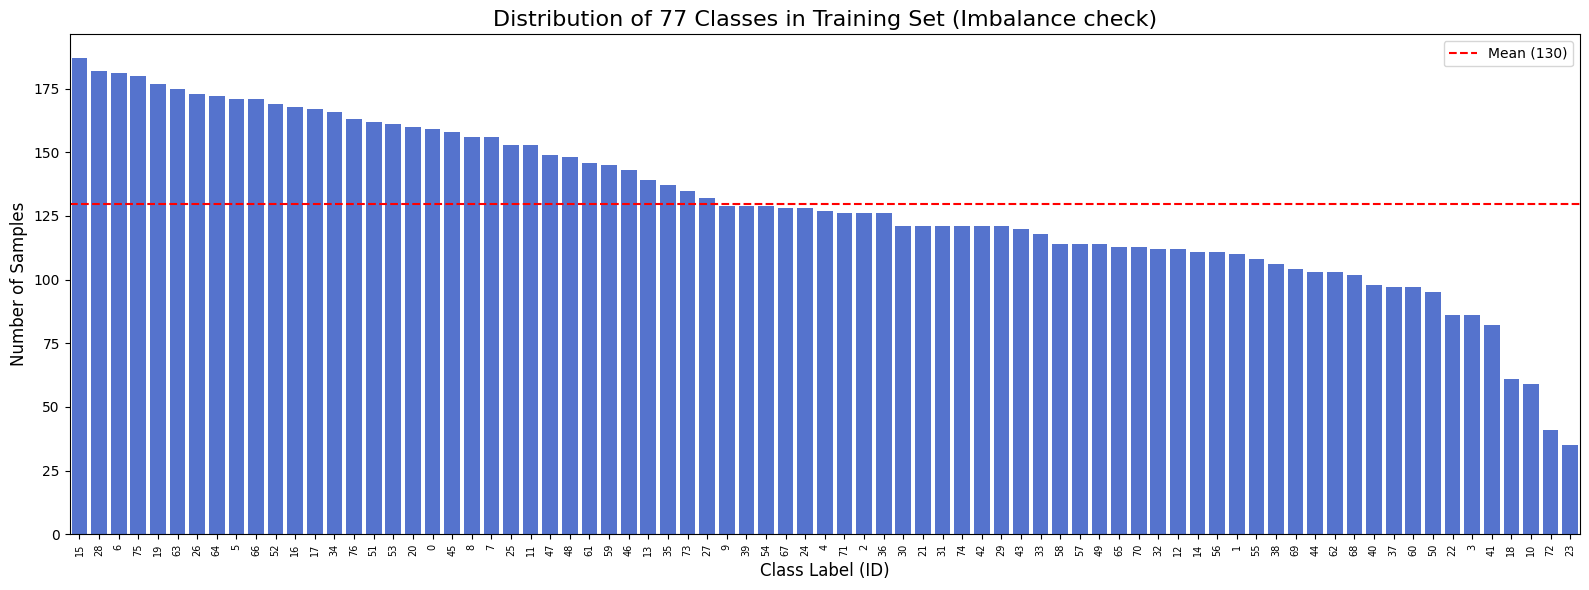


--- Text Length Statistics ---
Word Count Stats:
mean    11.955369
min      3.000000
max     79.000000
Name: word_count, dtype: float64

Character Length Stats:
mean     59.501351
min      13.000000
max     433.000000
Name: char_length, dtype: float64


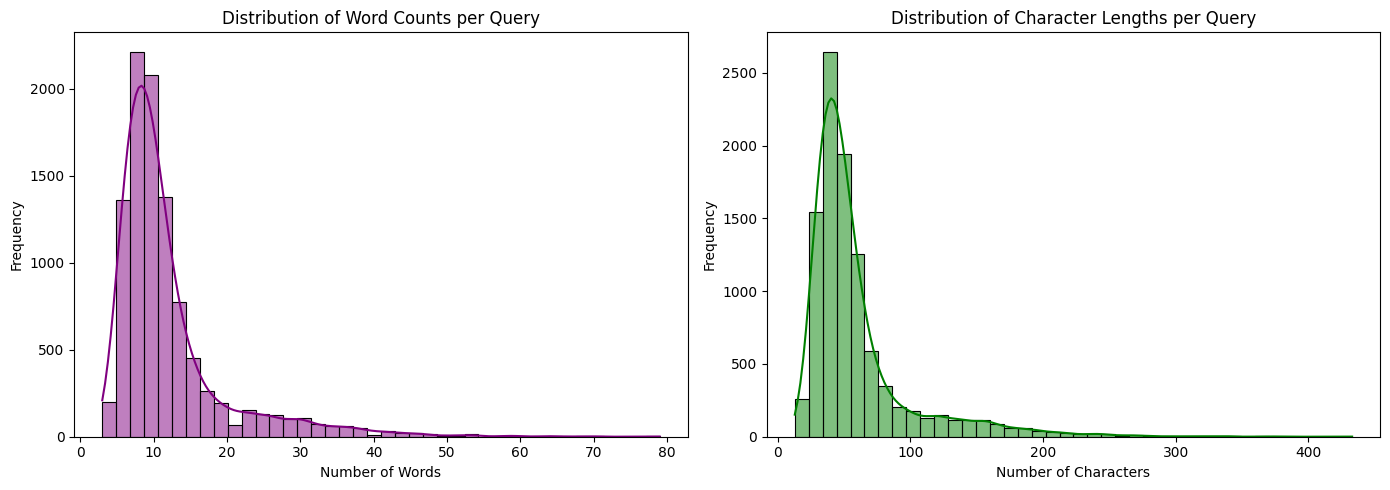

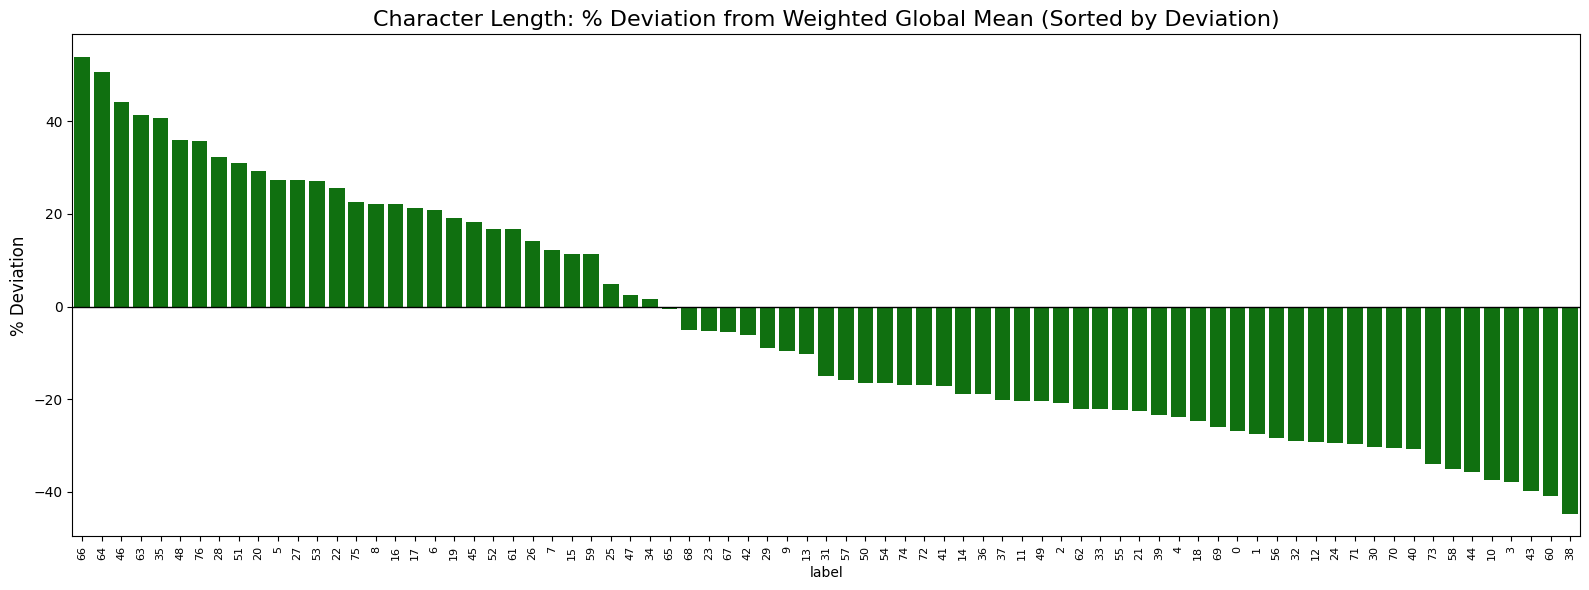

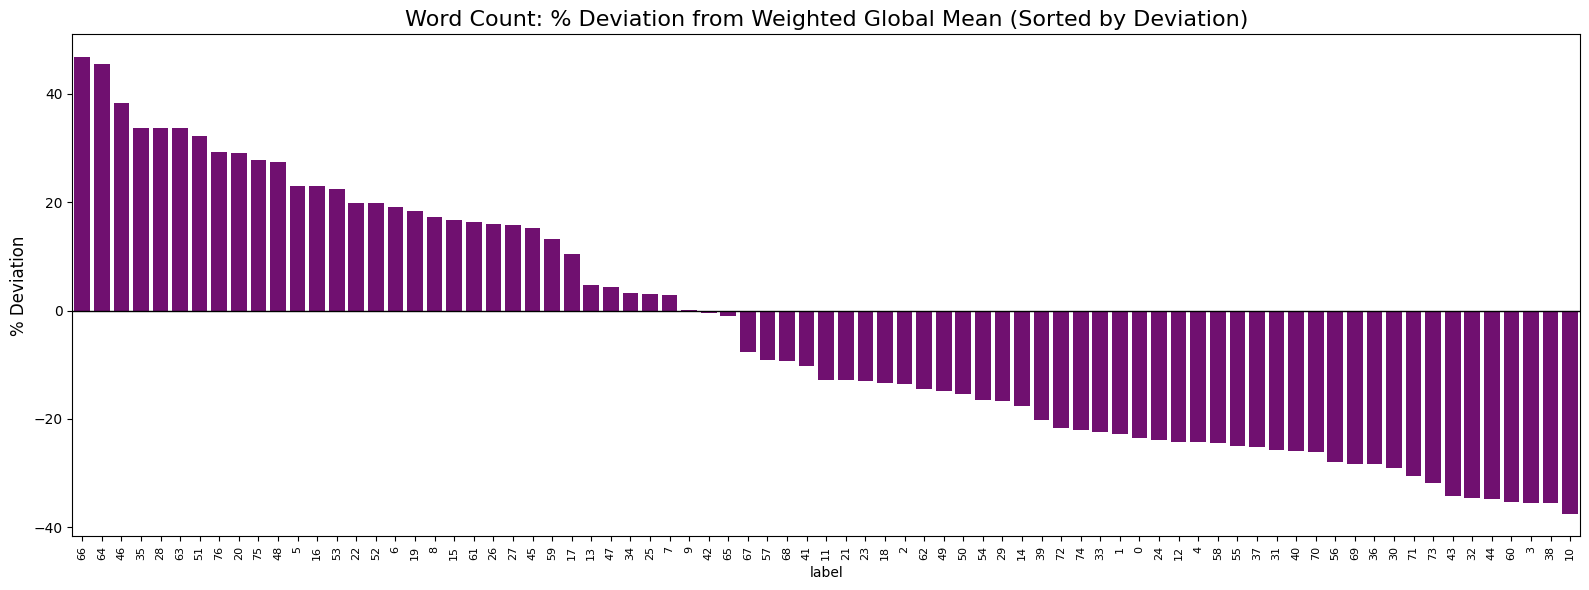

Weighted Baselines: 11.96 words, 59.50 characters


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Starting Exploratory Data Analysis on Train set...\n")

# --- 1. Class Distribution (Imbalance Check) ---
class_counts = train_df['label'].value_counts()

print("--- Class Distribution Statistics ---")
print(f"Total number of unique classes: {len(class_counts)}")
print(f"Largest class (Label ID {class_counts.idxmax()}): {class_counts.max()} samples")
print(f"Smallest class (Label ID {class_counts.idxmin()}): {class_counts.min()} samples")
print(f"Average samples per class: {class_counts.mean():.2f}")

# Plot 1: Histogram of Class Distribution
plt.figure(figsize=(16, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, color='royalblue', order=class_counts.index)
plt.title('Distribution of 77 Classes in Training Set (Imbalance check)', fontsize=16)
plt.xlabel('Class Label (ID)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.axhline(class_counts.mean(), color='red', linestyle='--', label=f'Mean ({class_counts.mean():.0f})')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Text Length Statistics ---
# Calculate character length and word count for each text
train_df['char_length'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

print("\n--- Text Length Statistics ---")
print("Word Count Stats:")
print(train_df['word_count'].describe().loc[['mean', 'min', 'max']])

print("\nCharacter Length Stats:")
print(train_df['char_length'].describe().loc[['mean', 'min', 'max']])

# Plot 2: Histograms of Text Lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot for Words (PURPLE)
sns.histplot(train_df['word_count'], bins=40, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribution of Word Counts per Query')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Subplot for Characters (GREEN)
sns.histplot(train_df['char_length'], bins=40, kde=True, color='green', ax=axes[1])
axes[1].set_title('Distribution of Character Lengths per Query')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# --- 3. Normalized Deviation Analysis (Added Code) ---

# Calculate Weighted Global Means to account for imbalance
total_samples = len(train_df)
class_stats = train_df.groupby('label')[['word_count', 'char_length']].mean()
weighted_mean_words = (class_stats['word_count'] * class_counts).sum() / total_samples
weighted_mean_chars = (class_stats['char_length'] * class_counts).sum() / total_samples

# Create normalization dataframe
class_means = class_stats.reset_index()

# Calculate % deviation from the weighted global baseline
class_means['char_norm'] = (class_means['char_length'] - weighted_mean_chars) / weighted_mean_chars * 100
class_means['word_norm'] = (class_means['word_count'] - weighted_mean_words) / weighted_mean_words * 100

# Plot 3: Normalized Character Length (GREEN - Sorted by Deviation)
plt.figure(figsize=(16, 6))
sorted_chars = class_means.sort_values('char_norm', ascending=False)
sns.barplot(data=sorted_chars, x='label', y='char_norm', color='green', order=sorted_chars['label'])
plt.axhline(0, color='black', linewidth=1)
plt.title('Character Length: % Deviation from Weighted Global Mean (Sorted by Deviation)', fontsize=16)
plt.ylabel('% Deviation', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

# Plot 4: Normalized Word Count (PURPLE - Sorted by Deviation)
plt.figure(figsize=(16, 6))
sorted_words = class_means.sort_values('word_norm', ascending=False)
sns.barplot(data=sorted_words, x='label', y='word_norm', color='purple', order=sorted_words['label'])
plt.axhline(0, color='black', linewidth=1)
plt.title('Word Count: % Deviation from Weighted Global Mean (Sorted by Deviation)', fontsize=16)
plt.ylabel('% Deviation', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Weighted Baselines: {weighted_mean_words:.2f} words, {weighted_mean_chars:.2f} characters")

## 1.3 Comparative Analysis of Preprocessing (on train)

In [3]:
from nltk.stem import PorterStemmer
import re
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Count unique tokens in original, stemmed, and lemmatized text
all_text = ' '.join(train_df['text'].astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)

stemmed_words = [stemmer.stem(w) for w in words]
lemmatized_words = [lemmatizer.lemmatize(w) for w in words]

print(f"Original unique vocabulary size: {len(set(words))}")
print(f"Stemmed unique vocabulary size: {len(set(stemmed_words))}")
print(f"Lemmatized unique vocabulary size: {len(set(lemmatized_words))}")

Original unique vocabulary size: 2340
Stemmed unique vocabulary size: 1669
Lemmatized unique vocabulary size: 2183


## Step 1.4: Exploratory Analysis of Special Tokens and Characters



### Step 1.4.1: Empirical Study of Numerical Tokens (Digits Distribution)

In [4]:

import re
from collections import Counter
import pandas as pd

# 1. Extract all sequences of digits from the training set
all_numbers = []
for text in train_df['text']:
    # Find all standalone or connected digit sequences
    numbers_in_text = re.findall(r'\d+', str(text))
    all_numbers.extend(numbers_in_text)

# 2. Calculate statistics
total_number_count = len(all_numbers)
unique_number_count = len(set(all_numbers))

print(f"--- Number Statistics in Training Set ---")
print(f"Total occurrences of numbers: {total_number_count}")
print(f"Unique numbers (tokens that inflate dimension d): {unique_number_count}")

# 3. Analyze lengths to see what kind of numbers we have
lengths = [len(num) for num in all_numbers]
length_counts = Counter(lengths)

print("\n--- Breakdown by Number of Digits ---")
for length, count in sorted(length_counts.items()):
    example_samples = [num for num in all_numbers if len(num) == length][:5]
    print(f"{length}-digit numbers: {count} occurrences | Examples: {example_samples}")

# 4. Corrected version using 'label' column
print("\n--- Context Samples of Texts Containing Numbers ---")
texts_with_numbers = train_df[train_df['text'].str.contains(r'\d', regex=True)].sample(5, random_state=42)

for idx, row in texts_with_numbers.iterrows():
    print(f"Label ID: {row['label']} | Text: {row['text']}")
    print("-" * 50)

--- Number Statistics in Training Set ---
Total occurrences of numbers: 277
Unique numbers (tokens that inflate dimension d): 26

--- Breakdown by Number of Digits ---
1-digit numbers: 140 occurrences | Examples: ['2', '1', '2', '1', '2']
2-digit numbers: 87 occurrences | Examples: ['00', '00', '16', '18', '18']
3-digit numbers: 44 occurrences | Examples: ['100', '100', '100', '100', '100']
4-digit numbers: 6 occurrences | Examples: ['2018', '1818', '2018', '2018', '2018']

--- Context Samples of Texts Containing Numbers ---
Label ID: 34 | Text: Why was I charged $1 in a transaction?
--------------------------------------------------
Label ID: 67 | Text: Its been 3 days, How long will my transfer take to get to my wallet?
--------------------------------------------------
Label ID: 75 | Text: So I just went to the ATM to get some cash.  I input that I needed 100 pounds but I only got 80.  I have the receipt  and I am in need of the extra money.  How do I go about obtaining the missing 

### Step 1.4.2: Semantic Relevance and Anchoring of the Currency Sign ($)

In [7]:
import pandas as pd

# 1. Count how many times '$' appears in the training set
dollar_count = train_df['text'].str.contains(r'\$', regex=True).sum()
print(f"Total rows containing '$': {dollar_count} out of {len(train_df)}")

# 2. See which intents (categories) use the dollar sign the most
if dollar_count > 0:
    print("\n--- Top 5 Intents using the '$' sign ---")
    dollar_intents = train_df[train_df['text'].str.contains(r'\$', regex=True)]
    print(dollar_intents['label'].value_counts().head(5))

Total rows containing '$': 65 out of 9993

--- Top 5 Intents using the '$' sign ---
label
34    36
75    24
20     4
6      1
Name: count, dtype: int64


## 1.5 Final Preprocessing Pipeline (Smart Cleaning & POS-Aware Lemmatization)

Based on the insights from steps 1.3 (choosing Lemmatization over Stemming to preserve financial semantics) and 1.4 (preserving original digits due to low unique cardinality and high semantic anchoring), we construct our final text processing pipeline.

To prevent **Data Leakage**, this function is applied symmetrically but completely isolated onto both the Training and Test datasets.

In [6]:
### Step 1.5: Applying Selected Preprocessing (Dynamic POS Lemmatization & Custom Filtering)

import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
!pip install -q contractions
import contractions
import re

lemmatizer = WordNetLemmatizer()

# Define the precise list of semantic noise words to remove (Stop Words)
STOP_WORDS_TO_REMOVE = {
    'the', 'a', 'an', 'and', 'or', 'but', 'of', 'to', 'for', 'with', 'by', 'on', 'at', 'from',
    'it', 'its', 'they', 'them', 'their', 'he', 'she', 'his', 'her', 'here', 'there', 'thus',
    'is', 'are', 'was', 'were', 'be', 'been', 'being'
}
# Note: Negation (not, no, never) and personal pronouns (i, my, you, your) are explicitly preserved.

def get_wordnet_pos(treebank_tag):
    """Map NLTK POS tags to WordNet POS formats."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return None

def smart_clean_text(text):
    # 1. Expand contractions (e.g., hasn't -> has not)
    text = contractions.fix(str(text))

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Inject spaces around critical punctuation (?, ., and $) to prevent word-sticking
    text = re.sub(r'([\?\.\$])', r' \1 ', text)

    # 4. Clean formatting: allow letters, numbers, spaces, ?, ., $, ', and -
    text = re.sub(r'[^a-z0-9\s\?\.\$\'\-]', '', text)

    # 5. Tokenize by splitting on whitespace and filtering empty tokens
    words = [word for word in text.split() if word.strip()]

    # 6. Apply Custom Stop Words Filtering
    words = [word for word in words if word not in STOP_WORDS_TO_REMOVE]

    if not words:
        return ""

    # 7. Apply dynamic POS tagging
    pos_tags = nltk.pos_tag(words)

    # 8. Perform POS-aware Lemmatization
    lemmatized_words = []
    for word, tag in pos_tags:
        # Skip punctuation marks from being handled by the lemmatizer
        if word in ['?', '.']:
            lemmatized_words.append(word)
            continue

        w_pos = get_wordnet_pos(tag)
        if w_pos is not None:
            lemmatized_words.append(lemmatizer.lemmatize(word, pos=w_pos))
        else:
            lemmatized_words.append(lemmatizer.lemmatize(word))

    return ' '.join(lemmatized_words)


# --- Execute Symmetrical Preprocessing Pipeline ---
print("Applying Preprocessing and Lemmatization to both Train and Test sets...")
train_df['clean_text'] = train_df['text'].apply(smart_clean_text)
test_df['clean_text'] = test_df['text'].apply(smart_clean_text)

# --- NEW: Quantitative Preprocessing Statistics ---
print("\n=== Preprocessing Quantitative Analytics ===")

# 1. Calculate vocabulary sizes
raw_all_words = ' '.join(train_df['text'].astype(str).tolist()).lower().split()
clean_all_words = ' '.join(train_df['clean_text'].astype(str).tolist()).split()

print(f"Raw Vocabulary Size (Unique Words): {len(set(raw_all_words))}")
print(f"Cleaned Vocabulary Size (Unique Feature Dimension d): {len(set(clean_all_words))}")
print(f"Vocabulary Reduction: {((len(set(raw_all_words)) - len(set(clean_all_words))) / len(set(raw_all_words))) * 100:.2f}%")

# 2. Calculate average document length
avg_raw_len = train_df['text'].str.split().str.len().mean()
avg_clean_len = train_df['clean_text'].str.split().str.len().mean()
print(f"Average sentence length BEFORE cleaning: {avg_raw_len:.2f} words")
print(f"Average sentence length AFTER cleaning : {avg_clean_len:.2f} tokens")

# --- Symmetrical Verification Check (Fixed Seed for Reproducibility) ---
print("\n--- Verification: Checking processed data samples ---")
random_indices = train_df.sample(5, random_state=42).index

for idx in random_indices:
    print(f"Original: {train_df.loc[idx, 'text']}")
    print(f"Cleaned : {train_df.loc[idx, 'clean_text']}")
    print("-" * 30)

print("\nPreprocessing complete. Dataset is structurally normalized and ready for Feature Extraction.")

Applying Preprocessing and Lemmatization to both Train and Test sets...

=== Preprocessing Quantitative Analytics ===
Raw Vocabulary Size (Unique Words): 4135
Cleaned Vocabulary Size (Unique Feature Dimension d): 1877
Vocabulary Reduction: 54.61%
Average sentence length BEFORE cleaning: 11.96 words
Average sentence length AFTER cleaning : 10.49 tokens

--- Verification: Checking processed data samples ---
Original: What are the limits to where my card will be accepted?
Cleaned : what limit where my card will accept ?
------------------------------
Original: I would like to change currency
Cleaned : i would like change currency
------------------------------
Original: I have lost my credit card in the ATM!
Cleaned : i have lose my credit card in atm
------------------------------
Original: My card still hasn't been delivered
Cleaned : my card still have not deliver
------------------------------
Original: Can you deliver the PIN separately?
Cleaned : can you deliver pin separately ?
---

# Step 2: Baseline Representation (TF-IDF)

In [ ]:
## Step 2: Baseline Representation (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize TF-IDF WITHOUT max_features (full vocabulary)
# Using 'tfidf_full' as the variable name
tfidf_full = TfidfVectorizer()

# 2. Fit and Transform
# We use 'clean_text' column from train_df and test_df
X_train_full = tfidf_full.fit_transform(train_df['clean_text'])
X_test_full = tfidf_full.transform(test_df['clean_text'])

# 3. Analyze the results
vocab_size = len(tfidf_full.get_feature_names_out())
print(f"Full vocabulary size (unique tokens): {vocab_size}")
print(f"Sparse matrix shape: {X_train_full.shape}")

# Calculate Sparsity (how much of the matrix is zeros)
non_zeros = X_train_full.nnz
total_elements = X_train_full.shape[0] * X_train_full.shape[1]
sparsity = (1 - (non_zeros / total_elements)) * 100
print(f"Matrix Sparsity: {sparsity:.2f}% (Percentage of zeros)")

# Let's peek at some features
import random
print(f"\nExample of features (10 random):")
print(random.sample(list(tfidf_full.get_feature_names_out()), 10))

Full vocabulary size (unique tokens): 2003
Sparse matrix shape: (9993, 2003)
Matrix Sparsity: 99.49% (Percentage of zeros)

Example of features (10 random):
['tell', 'expensive', 'refunds', 'non', 'friend', 'statements', 'american', 'sunglass', 'outgoing', 'finished']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import random
# 1. Initialize TF-IDF WITHOUT max_features (full vocabulary)
tfidf_full = TfidfVectorizer()

# 2. Fit and Transform
X_train_full = tfidf_full.fit_transform(train_df['clean_text'])
X_test_full = tfidf_full.transform(test_df['clean_text'])

# 3. Analyze the results
feature_names = tfidf_full.get_feature_names_out()
vocab_size = len(feature_names)
print(f"Full vocabulary size (unique tokens): {vocab_size}")
print(f"Sparse matrix shape: {X_train_full.shape}")

# Calculate Sparsity
non_zeros = X_train_full.nnz
total_elements = X_train_full.shape[0] * X_train_full.shape[1]
sparsity = (1 - (non_zeros / total_elements)) * 100
print(f"Matrix Sparsity: {sparsity:.2f}% (Percentage of zeros)")

# --- 4. Find 10 Most Used (Less-Sparse) Features ---
# סכימת ערכי ה-TF-IDF עבור כל עמודה (Feature) לרוחב כל המסמכים
feature_sums = np.asarray(X_train_full.sum(axis=0)).flatten()

# קבלת האינדקסים של 10 הערכים הגבוהים ביותר
top_10_indices = feature_sums.argsort()[-10:][::-1]

print("\n--- 10 Most Used (Less-Sparse) Features ---")
for idx in top_10_indices:
    print(f"Feature: '{feature_names[idx]}', Total TF-IDF Score: {feature_sums[idx]:.2f}")

# Let's peek at some features
print(f"\nExample of features (10 random):")
print(random.sample(list(feature_names), 10))



Full vocabulary size (unique tokens): 2003
Sparse matrix shape: (9993, 2003)
Matrix Sparsity: 99.49% (Percentage of zeros)

--- 10 Most Used (Less-Sparse) Features ---
Feature: 'be', Total TF-IDF Score: 789.16
Feature: 'my', Total TF-IDF Score: 746.57
Feature: 'to', Total TF-IDF Score: 594.90
Feature: 'do', Total TF-IDF Score: 586.46
Feature: 'card', Total TF-IDF Score: 545.49
Feature: 'the', Total TF-IDF Score: 532.50
Feature: 'not', Total TF-IDF Score: 427.30
Feature: 'can', Total TF-IDF Score: 384.14
Feature: 'how', Total TF-IDF Score: 368.20
Feature: 'have', Total TF-IDF Score: 363.65

Example of features (10 random):
['dispense', 'internet', 'history', 'embarrassed', 'london', 'cover', 'reapplying', 'disagree', 'transation', 'unauthorized']


## 2.5 LEMMATIZING TF-IDF

In [ ]:
## Step 2.5: TF-IDF after Lemmatization

import nltk
import re
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import random

nltk.download('wordnet', quiet=True)
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # המרה לאותיות קטנות ופירוק למילים נקיות מפיסוק בהתאם לבדיקה הידנית
    words = re.findall(r'\b\w+\b', str(text).lower())
    return " ".join([lemmatizer.lemmatize(w) for w in words])

# 1. הכנת הטקסט שעבר למטיזציה מיושרת
train_df['lemmatized_text'] = train_df['clean_text'].apply(lemmatize_text)
test_df['lemmatized_text'] = test_df['clean_text'].apply(lemmatize_text)

# 2. Initialize TF-IDF WITHOUT max_features
tfidf_lemmatized = TfidfVectorizer()

# 3. Fit and Transform
X_train_lemmatized = tfidf_lemmatized.fit_transform(train_df['lemmatized_text'])
X_test_lemmatized = tfidf_lemmatized.transform(test_df['lemmatized_text'])

# 4. Analyze the results
feature_names_lem = tfidf_lemmatized.get_feature_names_out()
vocab_size_lem = len(feature_names_lem)
print(f"Lemmatized vocabulary size (unique tokens): {vocab_size_lem}")
print(f"Sparse matrix shape: {X_train_lemmatized.shape}")

# Calculate Sparsity
non_zeros_lem = X_train_lemmatized.nnz
total_elements_lem = X_train_lemmatized.shape[0] * X_train_lemmatized.shape[1]
sparsity_lem = (1 - (non_zeros_lem / total_elements_lem)) * 100
print(f"Matrix Sparsity: {sparsity_lem:.2f}% (Percentage of zeros)")

# --- 5. Find 10 Most Used (Less-Sparse) Features ---
feature_sums_lem = np.asarray(X_train_lemmatized.sum(axis=0)).flatten()
top_10_indices_lem = feature_sums_lem.argsort()[-10:][::-1]

print("\n--- 10 Most Used (Less-Sparse) Features (Lemmatized) ---")
for idx in top_10_indices_lem:
    print(f"Feature: '{feature_names_lem[idx]}', Total TF-IDF Score: {feature_sums_lem[idx]:.2f}")

# Let's peek at some features
print(f"\nExample of features (10 random):")
print(random.sample(list(feature_names_lem), 10))

Lemmatized vocabulary size (unique tokens): 1905
Sparse matrix shape: (9993, 1905)
Matrix Sparsity: 99.46% (Percentage of zeros)

--- 10 Most Used (Less-Sparse) Features (Lemmatized) ---
Feature: 'be', Total TF-IDF Score: 795.34
Feature: 'my', Total TF-IDF Score: 749.78
Feature: 'to', Total TF-IDF Score: 598.86
Feature: 'do', Total TF-IDF Score: 590.97
Feature: 'card', Total TF-IDF Score: 563.36
Feature: 'the', Total TF-IDF Score: 537.64
Feature: 'not', Total TF-IDF Score: 428.61
Feature: 'can', Total TF-IDF Score: 387.35
Feature: 'how', Total TF-IDF Score: 371.45
Feature: 'have', Total TF-IDF Score: 365.76

Example of features (10 random):
['appropriate', 'replacement', '45', 'spending', 'bos', 'efficient', 'ruble', 'transferred', 'authorization', 'guess']


## 2.6 STEMMING TF-IDF

In [ ]:
## Step 2.6: TF-IDF after Stemming

from nltk.stem import PorterStemmer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import random

stemmer = PorterStemmer()

def stem_text(text):
    # המרה לאותיות קטנות ופירוק למילים נקיות מפיסוק בהתאם לבדיקה הידנית
    words = re.findall(r'\b\w+\b', str(text).lower())
    return " ".join([stemmer.stem(w) for w in words])

# 1. הכנת הטקסט שעבר סטמינג מיושר
train_df['stemmed_text'] = train_df['clean_text'].apply(stem_text)
test_df['stemmed_text'] = test_df['clean_text'].apply(stem_text)

# 2. Initialize TF-IDF WITHOUT max_features
tfidf_stemmed = TfidfVectorizer()

# 3. Fit and Transform
X_train_stemmed = tfidf_stemmed.fit_transform(train_df['stemmed_text'])
X_test_stemmed = tfidf_stemmed.transform(test_df['stemmed_text'])

# 4. Analyze the results
feature_names_stem = tfidf_stemmed.get_feature_names_out()
vocab_size_stem = len(feature_names_stem)
print(f"Stemmed vocabulary size (unique tokens): {vocab_size_stem}")
print(f"Sparse matrix shape: {X_train_stemmed.shape}")

# Calculate Sparsity
non_zeros_stem = X_train_stemmed.nnz
total_elements_stem = X_train_stemmed.shape[0] * X_train_stemmed.shape[1]
sparsity_stem = (1 - (non_zeros_stem / total_elements_stem)) * 100
print(f"Matrix Sparsity: {sparsity_stem:.2f}% (Percentage of zeros)")

# --- 5. Find 10 Most Used (Less-Sparse) Features ---
feature_sums_stem = np.asarray(X_train_stemmed.sum(axis=0)).flatten()
top_10_indices_stem = feature_sums_stem.argsort()[-10:][::-1]

print("\n--- 10 Most Used (Less-Sparse) Features (Stemmed) ---")
for idx in top_10_indices_stem:
    print(f"Feature: '{feature_names_stem[idx]}', Total TF-IDF Score: {feature_sums_stem[idx]:.2f}")

# Let's peek at some features
print(f"\nExample of features (10 random):")
print(random.sample(list(feature_names_stem), 10))

Stemmed vocabulary size (unique tokens): 1595
Sparse matrix shape: (9993, 1595)
Matrix Sparsity: 99.36% (Percentage of zeros)

--- 10 Most Used (Less-Sparse) Features (Stemmed) ---
Feature: 'be', Total TF-IDF Score: 811.88
Feature: 'my', Total TF-IDF Score: 762.90
Feature: 'to', Total TF-IDF Score: 605.72
Feature: 'do', Total TF-IDF Score: 598.21
Feature: 'card', Total TF-IDF Score: 572.37
Feature: 'the', Total TF-IDF Score: 543.88
Feature: 'not', Total TF-IDF Score: 437.52
Feature: 'can', Total TF-IDF Score: 391.78
Feature: 'how', Total TF-IDF Score: 375.70
Feature: 'have', Total TF-IDF Score: 371.93

Example of features (10 random):
['satisfi', 'unsuccess', 'length', 'stop', 'week', 'employ', 'paymentpurchas', 'closer', 'half', 'wrong']


## 2.7 Pos_Tagging TF-IDF

In [ ]:
## Step 2.7: TF-IDF after Smart POS Tagging & Guided Lemmatization

import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import random

# הורדת המשאב המעודכן עבור תיוג ה-POS באנגלית
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def smart_pos_and_guided_lemmatize(text):
    # 1. פירוק למילים ושמירה על אותיות רישיות/קטנות מקוריות עבור תיוג POS מדויק
    words = re.findall(r'\b\w+\b', str(text))
    pos_tags = nltk.pos_tag(words)

    smart_tokens = []
    for word, tag in pos_tags:
        w_pos = get_wordnet_pos(tag)
        word_lower = word.lower()

        # 2. שימוש בתיוג ה-POS רק לצורך בחירת הלמה הנכונה, ללא סינון מילים
        if w_pos is not None:
            smart_tokens.append(lemmatizer.lemmatize(word_lower, pos=w_pos))
        else:
            # אם התג אינו שם עצם/פועל/תואר/תואר הפועל (כמו מילות יחס או שאלות), נשמור אותו ללא שינוי או כלמה ברירת מחדל
            smart_tokens.append(lemmatizer.lemmatize(word_lower))

    return " ".join(smart_tokens)

# 1. הכנת הטקסט באמצעות עיבוד POS חכם ומיושר (מבוסס על עמודת ה-text המקורית ולא על clean_text)
train_df['smart_pos_text'] = train_df['clean_text'].apply(smart_pos_and_guided_lemmatize)
test_df['smart_pos_text'] = test_df['clean_text'].apply(smart_pos_and_guided_lemmatize)
# train_df['smart_pos_text'] = train_df['text'].apply(smart_pos_and_guided_lemmatize)
# test_df['smart_pos_text'] = test_df['text'].apply(smart_pos_and_guided_lemmatize)


# 2. Initialize TF-IDF WITHOUT max_features
tfidf_pos = TfidfVectorizer()

# 3. Fit and Transform
X_train_pos = tfidf_pos.fit_transform(train_df['smart_pos_text'])
X_test_pos = tfidf_pos.transform(test_df['smart_pos_text'])

# 4. Analyze the results
feature_names_pos = tfidf_pos.get_feature_names_out()
vocab_size_pos = len(feature_names_pos)
print(f"Smart POS vocabulary size (unique tokens): {vocab_size_pos}")
print(f"Sparse matrix shape: {X_train_pos.shape}")

# Calculate Sparsity
non_zeros_pos = X_train_pos.nnz
total_elements_pos = X_train_pos.shape[0] * X_train_pos.shape[1]
sparsity_pos = (1 - (non_zeros_pos / total_elements_pos)) * 100
print(f"Matrix Sparsity: {sparsity_pos:.2f}% (Percentage of zeros)")

# --- 5. Find 10 Most Used (Less-Sparse) Features ---
# סכימת ערכי ה-TF-IDF עבור כל עמודה (Feature) לרוחב כל המסמכים
feature_sums_pos = np.asarray(X_train_pos.sum(axis=0)).flatten()

# קבלת האינדקסים של 10 הערכים הגבוהים ביותר
top_10_indices_pos = feature_sums_pos.argsort()[-10:][::-1]

print("\n--- 10 Most Used (Less-Sparse) Features (Smart POS) ---")
for idx in top_10_indices_pos:
    print(f"Feature: '{feature_names_pos[idx]}', Total TF-IDF Score: {feature_sums_pos[idx]:.2f}")

# Let's peek at some features
print(f"\nExample of features (10 random):")
print(random.sample(list(feature_names_pos), 10))

Smart POS vocabulary size (unique tokens): 1791
Sparse matrix shape: (9993, 1791)
Matrix Sparsity: 99.43% (Percentage of zeros)

--- 10 Most Used (Less-Sparse) Features (Smart POS) ---
Feature: 'be', Total TF-IDF Score: 811.85
Feature: 'my', Total TF-IDF Score: 760.26
Feature: 'to', Total TF-IDF Score: 604.09
Feature: 'do', Total TF-IDF Score: 598.39
Feature: 'card', Total TF-IDF Score: 570.22
Feature: 'the', Total TF-IDF Score: 543.09
Feature: 'not', Total TF-IDF Score: 435.40
Feature: 'can', Total TF-IDF Score: 390.30
Feature: 'how', Total TF-IDF Score: 374.66
Feature: 'have', Total TF-IDF Score: 371.22

Example of features (10 random):
['pack', 'finance', 'deactivate', 'efficient', 'save', 'wedding', 'tack', 'thankyou', 'call', 'buyer']


## 2.8 Over-Stemming

In [ ]:
## Step 2.8: Demonstration of Over-Stemming using Banking77 Context

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

nltk.download('wordnet', quiet=True)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# מילים אמיתיות מתוך מילון המושגים של בעיית ה-Banking77 שלך
banking_vocabulary = [
    # דוגמה 1: כרטיסים ונושאי כרטיסים - הסטמר מאחד אותם בטעות לאותו Feature
    "card", "cardholder",

    # דוגמה 2: פקודות ביצוע מול מנהלים - הסטמר מאבד את ההבדל ביניהם
    "execute", "executive",

    # דוגמה 3: הפעלת שירותים מול אקטיביזם/פעולות - הסטמר חותך באופן עיוור
    "activate", "activation", "activity"
]

print("--- Over-Stemming Demonstration on Banking77 Vocabulary ---")
print(f"{'Original Word':<15} | {'Stemmed Feature':<15} | {'Smart POS Lemmatized':<15}")
print("-" * 55)

for word in banking_vocabulary:
    # 1. Stemming פשוט ואגרסיבי
    stemmed = stemmer.stem(word)

    # 2. Smart POS (דימוי של ה-POS שקובע אם המילה היא שם עצם או פועל בהתאם להקשר הבנקאי)
    if word in ["execute", "activate"]:
        pos_tag = wordnet.VERB
    else:
        pos_tag = wordnet.NOUN

    lemmatized = lemmatizer.lemmatize(word, pos=pos_tag)

    print(f"{word:<15} | {stemmed:<15} | {lemmatized:<15}")

--- Over-Stemming Demonstration on Banking77 Vocabulary ---
Original Word   | Stemmed Feature | Smart POS Lemmatized
-------------------------------------------------------
card            | card            | card           
cardholder      | cardhold        | cardholder     
execute         | execut          | execute        
executive       | execut          | executive      
activate        | activ           | activate       
activation      | activ           | activation     
activity        | activ           | activity       


### 2.8.1 new OverStemming

In [ ]:
## Step 2.8: Demonstration of Over-Stemming (Non-Intersection Showdown)

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from collections import defaultdict
import nltk
import re

nltk.download('wordnet', quiet=True)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# 1. Extract vocabulary dynamically from our dataset
words_in_dataset = set()
for text in train_df['text'].dropna():
    words_in_dataset.update(re.findall(r'\b\w+\b', text.lower()))

# 2. Find Lemma for each word based on its most frequent Part of Speech in the dataset
word_to_pos_tags = defaultdict(lambda: defaultdict(int))
for text in train_df['text'].dropna():
    words = re.findall(r'\b\w+\b', text.lower())
    tagged = nltk.pos_tag(words)
    for word, tag in tagged:
        w_pos = get_wordnet_pos(tag) if 'get_wordnet_pos' in globals() else None
        if w_pos:
            word_to_pos_tags[word][w_pos] += 1

word_to_lemma = {}
for word in words_in_dataset:
    pos_counts = word_to_pos_tags.get(word, {})
    if pos_counts:
        best_pos = max(pos_counts, key=pos_counts.get)
        word_to_lemma[word] = lemmatizer.lemmatize(word, pos=best_pos)
    else:
        word_to_lemma[word] = lemmatizer.lemmatize(word)

# 3. Group words by their stem
stem_to_words = defaultdict(set)
for word in words_in_dataset:
    stem_to_words[stemmer.stem(word)].add(word)

# 4. Find all stems collapsing words that map to different lemmas (the non-intersection)
showdown_candidates = []
for stem, words in stem_to_words.items():
    lemmas = {word_to_lemma[w] for w in words}
    if len(lemmas) > 1:
        showdown_candidates.append((stem, sorted(list(words)), sorted(list(lemmas))))

# 5. Sort candidates by the number of distinct lemmas collapsed, then by number of unique words
showdown_candidates.sort(key=lambda x: (len(x[2]), len(x[1])), reverse=True)

print("--- Stemming vs. POS-Guided Lemmatization Non-Intersection Showdown ---")
print(f"{'Stem':<15} | {'Unique Words (Dataset)':<50} | {'Lemmas Collapsed':<50}")
print("-" * 120)

for stem, words, lemmas in showdown_candidates[:20]: # Print top 20 showdowns
    words_str = ", ".join(words[:6]) + ("..." if len(words) > 6 else "")
    lemmas_str = ", ".join(lemmas[:6]) + ("..." if len(lemmas) > 6 else "")
    print(f"{stem:<15} | {words_str:<50} | {lemmas_str:<50}")

--- Stemming vs. POS-Guided Lemmatization Non-Intersection Showdown ---
Stem            | Unique Words (Dataset)                             | Lemmas Collapsed                                  
------------------------------------------------------------------------------------------------------------------------
activ           | activate, activated, activating, activation, active, activity | activate, activation, active, activity            
origin          | origin, original, originally, originate, originating | origin, original, originally, originate           
initi           | initial, initially, initiate, initiated, initiating | initial, initially, initiate, initiating          
tranfer         | tranfering, tranferred, tranferring, tranfers      | tranfering, tranferred, tranferring, tranfers     
valid           | valid, validate, validation, validity              | valid, validate, validation, validity             
allow           | allow, allowable, allowance, allowances, al

## 2.9 recap

In [ ]:
#print df
print(train_df.head())

                                                text  label    label_text  \
0                     I am still waiting on my card?     11  card_arrival   
1  What can I do if my card still hasn't arrived ...     11  card_arrival   
2  I have been waiting over a week. Is the card s...     11  card_arrival   
3  Can I track my card while it is in the process...     11  card_arrival   
4  How do I know if I will get my card, or if it ...     11  card_arrival   

   char_length  word_count                                         clean_text  \
0           30           7                        i be still wait on my card?   
1           60          13  what can i do if my card still have not arrive...   
2           58          12  i have be wait over a week. be the card still ...   
3           59          13  can i track my card while it be in the process...   
4           54          15  how do i know if i will get my card or if it b...   

                                     lemmatized_te

# Step 3: Baseline Models

## 3.1: Logistic Regression


### 3.1.0 Native LogReg

In [ ]:
## Step 3: Baseline (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Train the model using the variables from Step 2
# train_df['label'] is the column name for the target labels
print("Training Logistic Regression...")
log_reg.fit(X_train_full, train_df['label'])

# 3. Predict on Test set
y_pred = log_reg.predict(X_test_full)

# 4. Evaluate
accuracy = accuracy_score(test_df['label'], y_pred)
f1 = f1_score(test_df['label'], y_pred, average='weighted')

print(f"\n--- Baseline Results (Logistic Regression) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Baseline Results (Logistic Regression) ---
Accuracy: 0.8745
Weighted F1-Score: 0.8744


### 3.1.1 Lemmatization LogReg

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
log_reg_lem = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Train the model using the Lemmatized TF-IDF features
print("Training Logistic Regression (Lemmatized)...")
log_reg_lem.fit(X_train_lemmatized, train_df['label'])

# 3. Predict on Test set
y_pred_lem = log_reg_lem.predict(X_test_lemmatized)

# 4. Evaluate
accuracy_lem = accuracy_score(test_df['label'], y_pred_lem)
f1_lem = f1_score(test_df['label'], y_pred_lem, average='weighted')

print(f"\n--- Lemmatized Results (Logistic Regression) ---")
print(f"Accuracy: {accuracy_lem:.4f}")
print(f"Weighted F1-Score: {f1_lem:.4f}")

Training Logistic Regression (Lemmatized)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Lemmatized Results (Logistic Regression) ---
Accuracy: 0.8742
Weighted F1-Score: 0.8740


### 3.1.2 Stemming LogReg

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
log_reg_stem = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Train the model using the Stemmed TF-IDF features
print("Training Logistic Regression (Stemmed)...")
log_reg_stem.fit(X_train_stemmed, train_df['label'])

# 3. Predict on Test set
y_pred_stem = log_reg_stem.predict(X_test_stemmed)

# 4. Evaluate
accuracy_stem = accuracy_score(test_df['label'], y_pred_stem)
f1_stem = f1_score(test_df['label'], y_pred_stem, average='weighted')

print(f"\n--- Stemmed Results (Logistic Regression) ---")
print(f"Accuracy: {accuracy_stem:.4f}")
print(f"Weighted F1-Score: {f1_stem:.4f}")

Training Logistic Regression (Stemmed)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Stemmed Results (Logistic Regression) ---
Accuracy: 0.8817
Weighted F1-Score: 0.8816


### 3.1.3 Pos_Tag LogReg

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
log_reg_pos = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Train the model using the Smart POS Tagged TF-IDF features
print("Training Logistic Regression (Smart POS)...")
log_reg_pos.fit(X_train_pos, train_df['label'])

# 3. Predict on Test set
y_pred_pos = log_reg_pos.predict(X_test_pos)

# 4. Evaluate
accuracy_pos = accuracy_score(test_df['label'], y_pred_pos)
f1_pos = f1_score(test_df['label'], y_pred_pos, average='weighted')

print(f"\n--- Smart POS Results (Logistic Regression) ---")
print(f"Accuracy: {accuracy_pos:.4f}")
print(f"Weighted F1-Score: {f1_pos:.4f}")

Training Logistic Regression (Smart POS)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Smart POS Results (Logistic Regression) ---
Accuracy: 0.8800
Weighted F1-Score: 0.8799


### comparison

--- Logistic Regression Performance Comparison ---
             Preprocessing Method Accuracy Weighted F1-Score
         Native / Cleaned (3.1.0)   0.8745            0.8744
            Lemmatization (3.1.1)   0.8742            0.8740
                 Stemming (3.1.2)   0.8817            0.8816
Smart POS + Lemmatization (3.1.3)   0.8800            0.8799


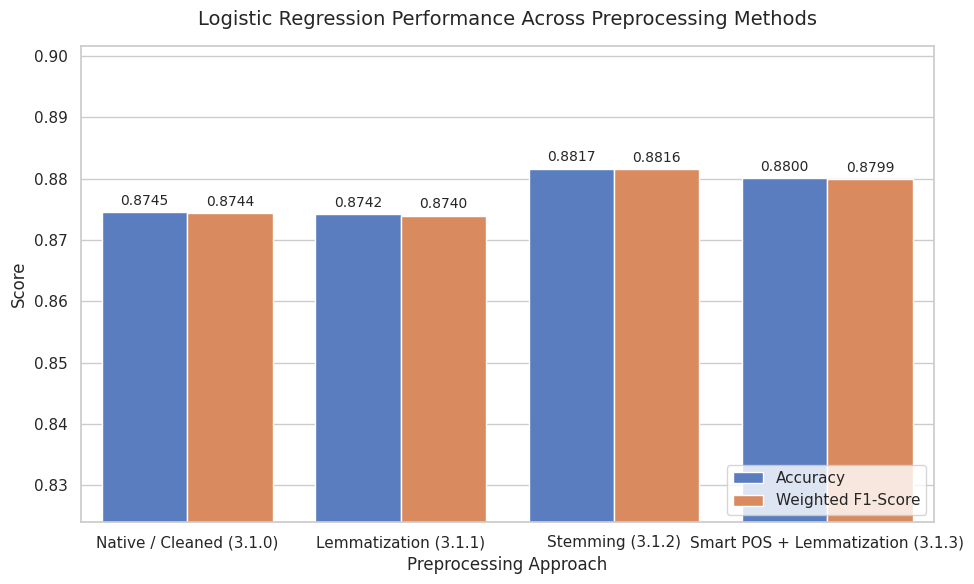

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gather all results into a dictionary
comparison_data = {
    "Preprocessing Method": [
        "Native / Cleaned (3.1.0)",
        "Lemmatization (3.1.1)",
        "Stemming (3.1.2)",
        "Smart POS + Lemmatization (3.1.3)"
    ],
    "Accuracy": [accuracy, accuracy_lem, accuracy_stem, accuracy_pos],
    "Weighted F1-Score": [f1, f1_lem, f1_stem, f1_pos]
}

# 2. Create and display the DataFrame
df_comparison = pd.DataFrame(comparison_data)
print("--- Logistic Regression Performance Comparison ---")
print(df_comparison.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Weighted F1-Score': '{:,.4f}'.format
}))

# 3. Melt the DataFrame for easy plotting with seaborn
df_melted = df_comparison.melt(
    id_vars="Preprocessing Method",
    var_name="Metric",
    value_name="Score"
)

# 4. Plot Comparison
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_melted,
    x="Preprocessing Method",
    y="Score",
    hue="Metric",
    palette="muted"
)

# Set visual limits and labels
min_score = df_melted["Score"].min()
plt.ylim(max(0, min_score - 0.05), min(1.0, df_melted["Score"].max() + 0.02))
plt.title("Logistic Regression Performance Across Preprocessing Methods", fontsize=14, pad=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Preprocessing Approach", fontsize=12)
plt.legend(loc="lower right")

# Add scores on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

## 3.2 Perceptron Algorithm

### 3.2.0 Native

In [ ]:
## 3.2 Perceptron Algorithm

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize Perceptron
# max_iter=1000 ensures it stops if it doesn't converge
# tol=1e-3 is the stopping criterion
perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# 2. Train
print("Training Perceptron...")
perceptron.fit(X_train_full, train_df['label'])

# 3. Predict
y_pred_perc = perceptron.predict(X_test_full)

# 4. Evaluate
accuracy_perc = accuracy_score(test_df['label'], y_pred_perc)
f1_perc = f1_score(test_df['label'], y_pred_perc, average='weighted')

print(f"\n--- Results (Perceptron) ---")
print(f"Accuracy: {accuracy_perc:.4f}")
print(f"Weighted F1-Score: {f1_perc:.4f}")

# Check convergence
print(f"Did it converge? {perceptron.n_iter_ < 1000}")

Training Perceptron...

--- Results (Perceptron) ---
Accuracy: 0.8375
Weighted F1-Score: 0.8385
Did it converge? True


### 3.2.1 Lemmatization

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
perc_lem = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# 2. Train the model using Lemmatized TF-IDF features
print("Training Perceptron (Lemmatized)...")
perc_lem.fit(X_train_lemmatized, train_df['label'])

# 3. Predict on Test set
y_pred_perc_lem = perc_lem.predict(X_test_lemmatized)

# 4. Evaluate
accuracy_perc_lem = accuracy_score(test_df['label'], y_pred_perc_lem)
f1_perc_lem = f1_score(test_df['label'], y_pred_perc_lem, average='weighted')

print(f"\n--- Lemmatized Results (Perceptron) ---")
print(f"Accuracy: {accuracy_perc_lem:.4f}")
print(f"Weighted F1-Score: {f1_perc_lem:.4f}")
print(f"Did it converge? {perc_lem.n_iter_ < 1000}")

Training Perceptron (Lemmatized)...

--- Lemmatized Results (Perceptron) ---
Accuracy: 0.8469
Weighted F1-Score: 0.8461
Did it converge? True


### 3.2.2 Stemming

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
perc_stem = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# 2. Train the model using Stemmed TF-IDF features
print("Training Perceptron (Stemmed)...")
perc_stem.fit(X_train_stemmed, train_df['label'])

# 3. Predict on Test set
y_pred_perc_stem = perc_stem.predict(X_test_stemmed)

# 4. Evaluate
accuracy_perc_stem = accuracy_score(test_df['label'], y_pred_perc_stem)
f1_perc_stem = f1_score(test_df['label'], y_pred_perc_stem, average='weighted')

print(f"\n--- Stemmed Results (Perceptron) ---")
print(f"Accuracy: {accuracy_perc_stem:.4f}")
print(f"Weighted F1-Score: {f1_perc_stem:.4f}")
print(f"Did it converge? {perc_stem.n_iter_ < 1000}")

Training Perceptron (Stemmed)...

--- Stemmed Results (Perceptron) ---
Accuracy: 0.8417
Weighted F1-Score: 0.8411
Did it converge? True


### 3.2.3 Pos_Tag

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the model
perc_pos = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# 2. Train the model using Smart POS Tagged TF-IDF features
print("Training Perceptron (Smart POS)...")
perc_pos.fit(X_train_pos, train_df['label'])

# 3. Predict on Test set
y_pred_perc_pos = perc_pos.predict(X_test_pos)

# 4. Evaluate
accuracy_perc_pos = accuracy_score(test_df['label'], y_pred_perc_pos)
f1_perc_pos = f1_score(test_df['label'], y_pred_perc_pos, average='weighted')

print(f"\n--- Smart POS Results (Perceptron) ---")
print(f"Accuracy: {accuracy_perc_pos:.4f}")
print(f"Weighted F1-Score: {f1_perc_pos:.4f}")
print(f"Did it converge? {perc_pos.n_iter_ < 1000}")

Training Perceptron (Smart POS)...

--- Smart POS Results (Perceptron) ---
Accuracy: 0.8501
Weighted F1-Score: 0.8499
Did it converge? True


### comparison

--- Perceptron Performance Comparison ---
             Preprocessing Method Accuracy Weighted F1-Score
         Native / Cleaned (3.2.0)   0.8375            0.8385
            Lemmatization (3.2.1)   0.8469            0.8461
                 Stemming (3.2.2)   0.8417            0.8411
Smart POS + Lemmatization (3.2.3)   0.8501            0.8499


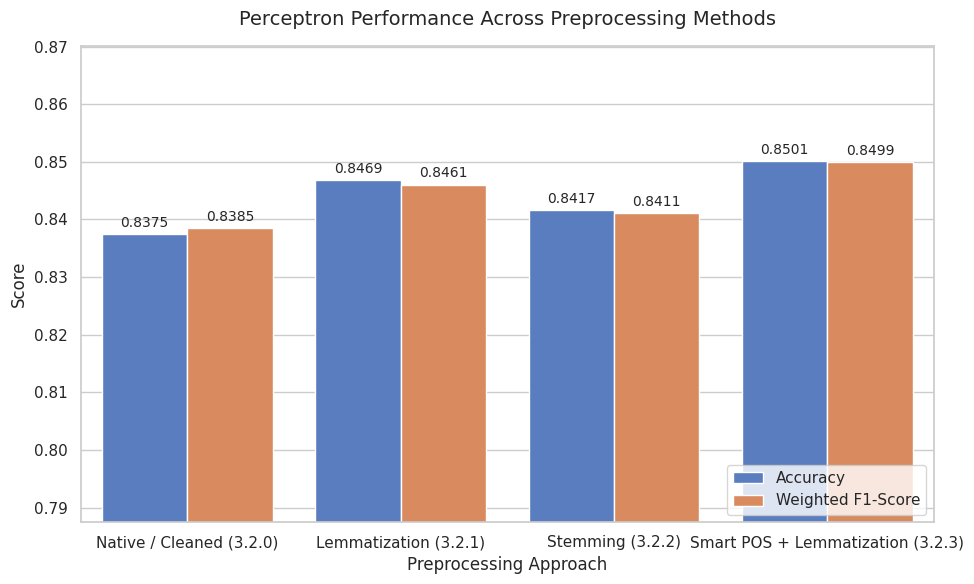

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gather all Perceptron results
comparison_data_perc = {
    "Preprocessing Method": [
        "Native / Cleaned (3.2.0)",
        "Lemmatization (3.2.1)",
        "Stemming (3.2.2)",
        "Smart POS + Lemmatization (3.2.3)"
    ],
    "Accuracy": [accuracy_perc, accuracy_perc_lem, accuracy_perc_stem, accuracy_perc_pos],
    "Weighted F1-Score": [f1_perc, f1_perc_lem, f1_perc_stem, f1_perc_pos]
}

# 2. Create and display DataFrame
df_comparison_perc = pd.DataFrame(comparison_data_perc)
print("--- Perceptron Performance Comparison ---")
print(df_comparison_perc.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Weighted F1-Score': '{:,.4f}'.format
}))

# 3. Melt DataFrame for Seaborn plot
df_melted_perc = df_comparison_perc.melt(
    id_vars="Preprocessing Method",
    var_name="Metric",
    value_name="Score"
)

# 4. Plot Comparison
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_melted_perc,
    x="Preprocessing Method",
    y="Score",
    hue="Metric",
    palette="muted"
)

min_score = df_melted_perc["Score"].min()
plt.ylim(max(0, min_score - 0.05), min(1.0, df_melted_perc["Score"].max() + 0.02))
plt.title("Perceptron Performance Across Preprocessing Methods", fontsize=14, pad=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Preprocessing Approach", fontsize=12)
plt.legend(loc="lower right")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

## 3.3 Winnow Algorithm

### 3.3.0 Native

In [ ]:
## 3.3 Winnow Algorithm

from sklearn.linear_model import SGDClassifier
import numpy as np

# Winnow is essentially a multiplicative update algorithm.
# We can approximate it using SGDClassifier with 'log_loss' or by
# using a specific implementation. Here is a robust way to run it:
winnow = SGDClassifier(loss='log_loss', penalty='l1', alpha=0.0001, learning_rate='constant', eta0=0.1)

# 1. Train
print("Training Winnow (SGD Approximation)...")
winnow.fit(X_train_full, train_df['label'])

# 2. Predict
y_pred_winnow = winnow.predict(X_test_full)

# 3. Evaluate
from sklearn.metrics import accuracy_score, f1_score
accuracy_winnow = accuracy_score(test_df['label'], y_pred_winnow)
f1_winnow = f1_score(test_df['label'], y_pred_winnow, average='weighted')

print(f"\n--- Results (Winnow Approximation) ---")
print(f"Accuracy: {accuracy_winnow:.4f}")
print(f"Weighted F1-Score: {f1_winnow:.4f}")

# 4. Feature Importance Analysis (The "Meat" for the report)
feature_names = tfidf_full.get_feature_names_out()
# Get weights for a specific class (e.g., class 0)
weights = winnow.coef_[0]
top_indices = np.argsort(weights)[-10:]
print(f"\nTop 10 most important features for class 0:")
for i in top_indices:
    print(f"{feature_names[i]}: {weights[i]:.4f}")

Training Winnow (SGD Approximation)...

--- Results (Winnow Approximation) ---
Accuracy: 0.8296
Weighted F1-Score: 0.8281

Top 10 most important features for class 0:
just: 0.0878
assist: 0.1356
ready: 0.1604
process: 0.2320
start: 0.8701
new: 1.4861
active: 1.7401
activated: 5.3080
activation: 7.0826
activate: 14.2898


### 3.3.1 Lemmatization

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# 1. Initialize Winnow (SGD Approximation)
winnow_lem = SGDClassifier(loss='log_loss', penalty='l1', alpha=0.0001, learning_rate='constant', eta0=0.1, random_state=42)

# 2. Train using Lemmatized TF-IDF features
print("Training Winnow (Lemmatized)...")
winnow_lem.fit(X_train_lemmatized, train_df['label'])

# 3. Predict on Test set
y_pred_winnow_lem = winnow_lem.predict(X_test_lemmatized)

# 4. Evaluate
accuracy_winnow_lem = accuracy_score(test_df['label'], y_pred_winnow_lem)
f1_winnow_lem = f1_score(test_df['label'], y_pred_winnow_lem, average='weighted')

print(f"\n--- Lemmatized Results (Winnow Approximation) ---")
print(f"Accuracy: {accuracy_winnow_lem:.4f}")
print(f"Weighted F1-Score: {f1_winnow_lem:.4f}")

# 5. Feature Importance Analysis
feature_names_lem = tfidf_lemmatized.get_feature_names_out()
weights_lem = winnow_lem.coef_[0]
top_indices_lem = np.argsort(weights_lem)[-10:]
print(f"\nTop 10 most important features for class 0 (Lemmatized):")
for i in top_indices_lem:
    print(f"{feature_names_lem[i]}: {weights_lem[i]:.4f}")

Training Winnow (Lemmatized)...

--- Lemmatized Results (Winnow Approximation) ---
Accuracy: 0.8332
Weighted F1-Score: 0.8318

Top 10 most important features for class 0 (Lemmatized):
just: 0.1010
ready: 0.1315
assist: 0.1405
process: 0.2227
start: 0.8839
new: 1.4445
active: 1.6968
activated: 5.2695
activation: 7.0479
activate: 14.1747


### 3.3.2 Stemming

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# 1. Initialize Winnow (SGD Approximation)
winnow_stem = SGDClassifier(loss='log_loss', penalty='l1', alpha=0.0001, learning_rate='constant', eta0=0.1, random_state=42)

# 2. Train using Stemmed TF-IDF features
print("Training Winnow (Stemmed)...")
winnow_stem.fit(X_train_stemmed, train_df['label'])

# 3. Predict on Test set
y_pred_winnow_stem = winnow_stem.predict(X_test_stemmed)

# 4. Evaluate
accuracy_winnow_stem = accuracy_score(test_df['label'], y_pred_winnow_stem)
f1_winnow_stem = f1_score(test_df['label'], y_pred_winnow_stem, average='weighted')

print(f"\n--- Stemmed Results (Winnow Approximation) ---")
print(f"Accuracy: {accuracy_winnow_stem:.4f}")
print(f"Weighted F1-Score: {f1_winnow_stem:.4f}")

# 5. Feature Importance Analysis
feature_names_stem = tfidf_stemmed.get_feature_names_out()
weights_stem = winnow_stem.coef_[0]
top_indices_stem = np.argsort(weights_stem)[-10:]
print(f"\nTop 10 most important features for class 0 (Stemmed):")
for i in top_indices_stem:
    print(f"{feature_names_stem[i]}: {weights_stem[i]:.4f}")

Training Winnow (Stemmed)...

--- Stemmed Results (Winnow Approximation) ---
Accuracy: 0.8407
Weighted F1-Score: 0.8402

Top 10 most important features for class 0 (Stemmed):
gather: 0.0000
gain: 0.0000
step: 0.0882
readi: 0.1993
just: 0.2209
assist: 0.2456
renew: 0.5127
start: 0.9021
new: 1.2837
activ: 14.7221


### 3.3.3 Pos_Tag

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# 1. Initialize Winnow (SGD Approximation)
winnow_pos = SGDClassifier(loss='log_loss', penalty='l1', alpha=0.0001, learning_rate='constant', eta0=0.1, random_state=42)

# 2. Train using Smart POS Tagged TF-IDF features
print("Training Winnow (Smart POS)...")
winnow_pos.fit(X_train_pos, train_df['label'])

# 3. Predict on Test set
y_pred_winnow_pos = winnow_pos.predict(X_test_pos)

# 4. Evaluate
accuracy_winnow_pos = accuracy_score(test_df['label'], y_pred_winnow_pos)
f1_winnow_pos = f1_score(test_df['label'], y_pred_winnow_pos, average='weighted')

print(f"\n--- Smart POS Results (Winnow Approximation) ---")
print(f"Accuracy: {accuracy_winnow_pos:.4f}")
print(f"Weighted F1-Score: {f1_winnow_pos:.4f}")

# 5. Feature Importance Analysis
feature_names_pos = tfidf_pos.get_feature_names_out()
weights_pos = winnow_pos.coef_[0]
top_indices_pos = np.argsort(weights_pos)[-10:]
print(f"\nTop 10 most important features for class 0 (Smart POS):")
for i in top_indices_pos:
    print(f"{feature_names_pos[i]}: {weights_pos[i]:.4f}")

Training Winnow (Smart POS)...

--- Smart POS Results (Winnow Approximation) ---
Accuracy: 0.8423
Weighted F1-Score: 0.8417

Top 10 most important features for class 0 (Smart POS):
ready: 0.1275
assist: 0.1682
process: 0.1899
just: 0.2252
renew: 0.5665
start: 0.8706
new: 1.0744
active: 1.5900
activation: 6.8693
activate: 14.3648


### comparison

--- Winnow Performance Comparison ---
             Preprocessing Method Accuracy Weighted F1-Score
         Native / Cleaned (3.3.0)   0.8296            0.8281
            Lemmatization (3.3.1)   0.8332            0.8318
                 Stemming (3.3.2)   0.8407            0.8402
Smart POS + Lemmatization (3.3.3)   0.8423            0.8417


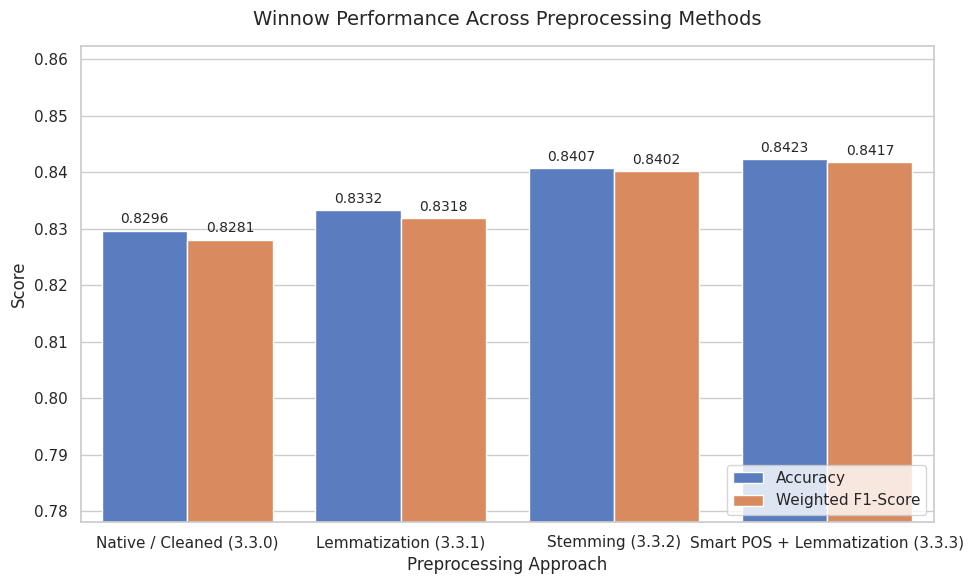

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gather all Winnow results
comparison_data_winnow = {
    "Preprocessing Method": [
        "Native / Cleaned (3.3.0)",
        "Lemmatization (3.3.1)",
        "Stemming (3.3.2)",
        "Smart POS + Lemmatization (3.3.3)"
    ],
    "Accuracy": [accuracy_winnow, accuracy_winnow_lem, accuracy_winnow_stem, accuracy_winnow_pos],
    "Weighted F1-Score": [f1_winnow, f1_winnow_lem, f1_winnow_stem, f1_winnow_pos]
}

# 2. Create and display DataFrame
df_comparison_winnow = pd.DataFrame(comparison_data_winnow)
print("--- Winnow Performance Comparison ---")
print(df_comparison_winnow.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Weighted F1-Score': '{:,.4f}'.format
}))

# 3. Melt DataFrame for Seaborn plot
df_melted_winnow = df_comparison_winnow.melt(
    id_vars="Preprocessing Method",
    var_name="Metric",
    value_name="Score"
)

# 4. Plot Comparison
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_melted_winnow,
    x="Preprocessing Method",
    y="Score",
    hue="Metric",
    palette="muted"
)

min_score = df_melted_winnow["Score"].min()
plt.ylim(max(0, min_score - 0.05), min(1.0, df_melted_winnow["Score"].max() + 0.02))
plt.title("Winnow Performance Across Preprocessing Methods", fontsize=14, pad=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Preprocessing Approach", fontsize=12)
plt.legend(loc="lower right")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

## 3.4 Overall Comparison

--- Overall Model Comparison (Accuracy Only) ---
     Preprocessing Method Logistic Regression Perceptron Winnow
         Native / Cleaned              0.8745     0.8375 0.8296
            Lemmatization              0.8742     0.8469 0.8332
                 Stemming              0.8817     0.8417 0.8407
Smart POS + Lemmatization              0.8800     0.8501 0.8423


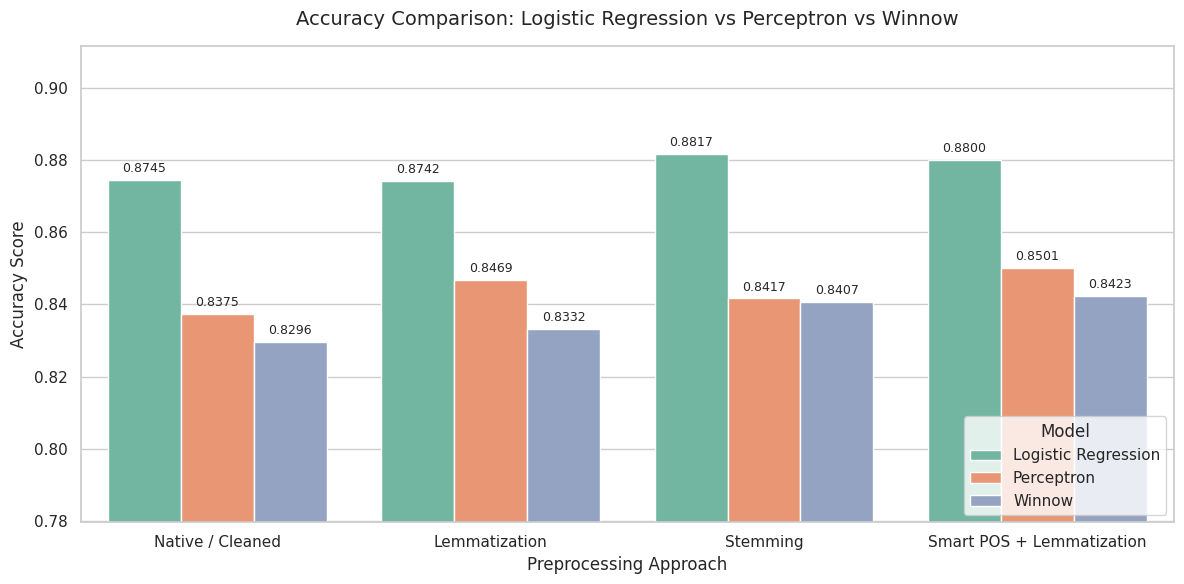

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gather Accuracy results across all 3 models and 4 preprocessing techniques
overall_accuracy_data = {
    "Preprocessing Method": [
        "Native / Cleaned",
        "Lemmatization",
        "Stemming",
        "Smart POS + Lemmatization"
    ],
    "Logistic Regression": [accuracy, accuracy_lem, accuracy_stem, accuracy_pos],
    "Perceptron": [accuracy_perc, accuracy_perc_lem, accuracy_perc_stem, accuracy_perc_pos],
    "Winnow": [accuracy_winnow, accuracy_winnow_lem, accuracy_winnow_stem, accuracy_winnow_pos]
}

# 2. Create and display DataFrame
df_overall_acc = pd.DataFrame(overall_accuracy_data)
print("--- Overall Model Comparison (Accuracy Only) ---")
print(df_overall_acc.to_string(index=False, formatters={
    'Logistic Regression': '{:,.4f}'.format,
    'Perceptron': '{:,.4f}'.format,
    'Winnow': '{:,.4f}'.format
}))

# 3. Melt DataFrame for multi-bar comparison plot
df_overall_melted = df_overall_acc.melt(
    id_vars="Preprocessing Method",
    var_name="Model",
    value_name="Accuracy"
)

# 4. Plot Comparison
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_overall_melted,
    x="Preprocessing Method",
    y="Accuracy",
    hue="Model",
    palette="Set2"
)

min_score = df_overall_melted["Accuracy"].min()
plt.ylim(max(0, min_score - 0.05), min(1.0, df_overall_melted["Accuracy"].max() + 0.03))
plt.title("Accuracy Comparison: Logistic Regression vs Perceptron vs Winnow", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Preprocessing Approach", fontsize=12)
plt.legend(title="Model", loc="lower right")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

# Step 4: Representation Optimization (Dimensionality Reduction & Embeddings)

## 4.1 Dimensionality Analysis (Truncated SVD)

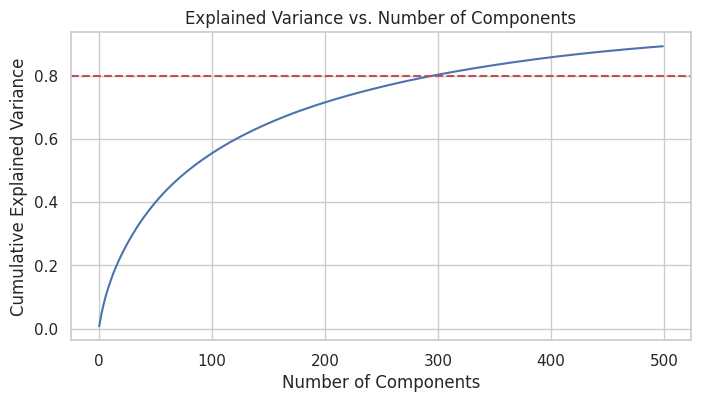

Number of components needed for 80% variance: 295


In [ ]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Apply SVD with 500 components to analyze explained variance
svd = TruncatedSVD(n_components=500, random_state=42)
svd.fit(X_train_full)

# Plot cumulative explained variance to identify the 'elbow'
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance)
plt.axhline(y=0.8, color='r', linestyle='--') # Threshold line at 80%
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Print the number of components needed for 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
print(f"Number of components needed for 80% variance: {n_components_80}")

### 4.1.2 try graph

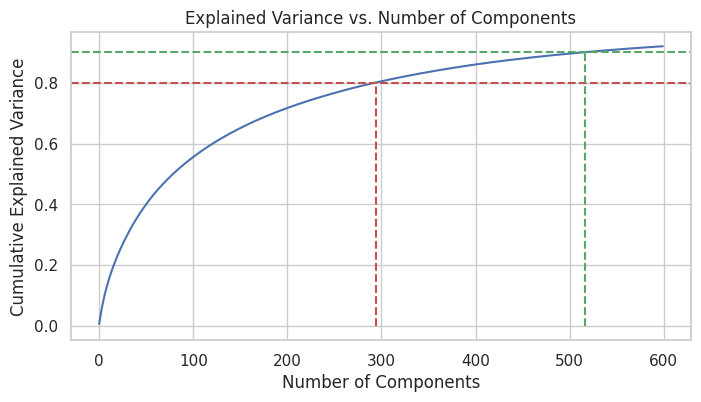

Number of components needed for 80% variance: 295
Number of components needed for 90% variance: 517


In [ ]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Apply SVD with 500 components to analyze explained variance
svd = TruncatedSVD(n_components=600, random_state=42)
svd.fit(X_train_full)

# Plot cumulative explained variance to identify the 'elbow'
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance)

# Identify indices for 80% and 90% variance
idx_80 = np.argmax(cumulative_variance >= 0.8)
idx_90 = np.argmax(cumulative_variance >= 0.9)

# Horizontal threshold lines
plt.axhline(y=0.8, color='r', linestyle='--')
plt.axhline(y=0.9, color='g', linestyle='--')

# Vertical lines from the intersection down to the x-axis
plt.vlines(x=idx_80, ymin=0, ymax=0.8, colors='r', linestyles='--')
plt.vlines(x=idx_90, ymin=0, ymax=0.9, colors='g', linestyles='--')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Print the number of components needed
print(f"Number of components needed for 80% variance: {idx_80 + 1}")
print(f"Number of components needed for 90% variance: {idx_90 + 1}")

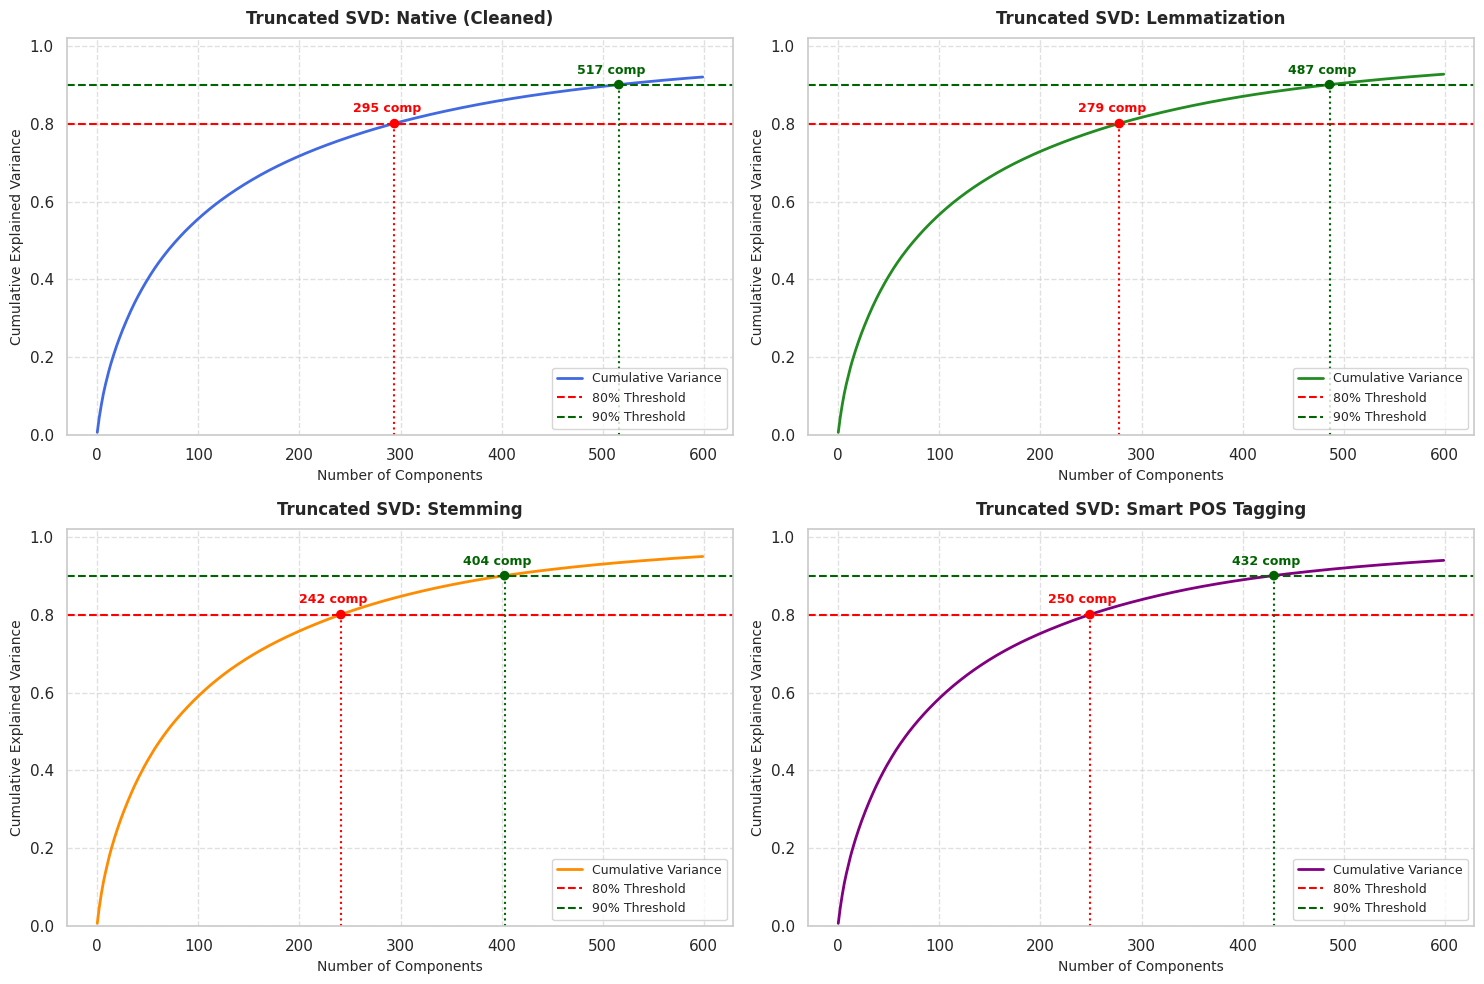

--- Dimensionality Analysis Summary (Truncated SVD) ---
Model: Native (Cleaned)          | 80% Variance: 295 comps | 90% Variance: 517 comps
Model: Lemmatization             | 80% Variance: 279 comps | 90% Variance: 487 comps
Model: Stemming                  | 80% Variance: 242 comps | 90% Variance: 404 comps
Model: Smart POS Tagging         | 80% Variance: 250 comps | 90% Variance: 432 comps


In [ ]:
"""### 4.1.2 Dimensionality Analysis Comparison across Preprocessing Models"""

from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Define the 4 preprocessing feature matrices and graph styling
preprocessing_models = [
    {"name": "Native (Cleaned)", "data": X_train_full, "color": "royalblue"},
    {"name": "Lemmatization", "data": X_train_lemmatized, "color": "forestgreen"},
    {"name": "Stemming", "data": X_train_stemmed, "color": "darkorange"},
    {"name": "Smart POS Tagging", "data": X_train_pos, "color": "purple"}
]

n_components = 600

# Set up a 2x2 grid for individual graphs
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

results = []

for idx, model_info in enumerate(preprocessing_models):
    ax = axes[idx]
    name = model_info["name"]
    X_matrix = model_info["data"]
    line_color = model_info["color"]

    # 1. Fit SVD on the model's feature matrix
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    svd.fit(X_matrix)

    # 2. Calculate cumulative explained variance
    cum_var = np.cumsum(svd.explained_variance_ratio_)

    # 3. Identify component count indices for 80% and 90% variance
    idx_80 = np.argmax(cum_var >= 0.8)
    idx_90 = np.argmax(cum_var >= 0.9)

    comp_80 = idx_80 + 1
    comp_90 = idx_90 + 1

    results.append({
        "Model": name,
        "Components 80%": comp_80,
        "Components 90%": comp_90
    })

    # 4. Plot Cumulative Explained Variance curve
    ax.plot(cum_var, label='Cumulative Variance', color=line_color, linewidth=2)

    # 5. Horizontal threshold lines for 80% and 90%
    ax.axhline(y=0.8, color='red', linestyle='--', linewidth=1.5, label='80% Threshold')
    ax.axhline(y=0.9, color='darkgreen', linestyle='--', linewidth=1.5, label='90% Threshold')

    # 6. Vertical lines from intersections down to the x-axis
    ax.vlines(x=idx_80, ymin=0, ymax=0.8, colors='red', linestyles=':', linewidth=1.5)
    ax.vlines(x=idx_90, ymin=0, ymax=0.9, colors='darkgreen', linestyles=':', linewidth=1.5)

    # Highlight intersection points with markers & text annotations
    ax.scatter([idx_80, idx_90], [0.8, 0.9], color=['red', 'darkgreen'], zorder=5, s=35)
    ax.annotate(f"{comp_80} comp", (idx_80, 0.8), textcoords="offset points", xytext=(-30, 8),
                color='red', fontweight='bold', fontsize=9)
    ax.annotate(f"{comp_90} comp", (idx_90, 0.9), textcoords="offset points", xytext=(-30, 8),
                color='darkgreen', fontweight='bold', fontsize=9)

    # Chart styling
    ax.set_title(f'Truncated SVD: {name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Number of Components', fontsize=10)
    ax.set_ylabel('Cumulative Explained Variance', fontsize=10)
    ax.set_ylim(0, 1.02)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table of components required
print("--- Dimensionality Analysis Summary (Truncated SVD) ---")
for res in results:
    print(f"Model: {res['Model']:<25} | 80% Variance: {res['Components 80%']:3d} comps | 90% Variance: {res['Components 90%']:3d} comps")

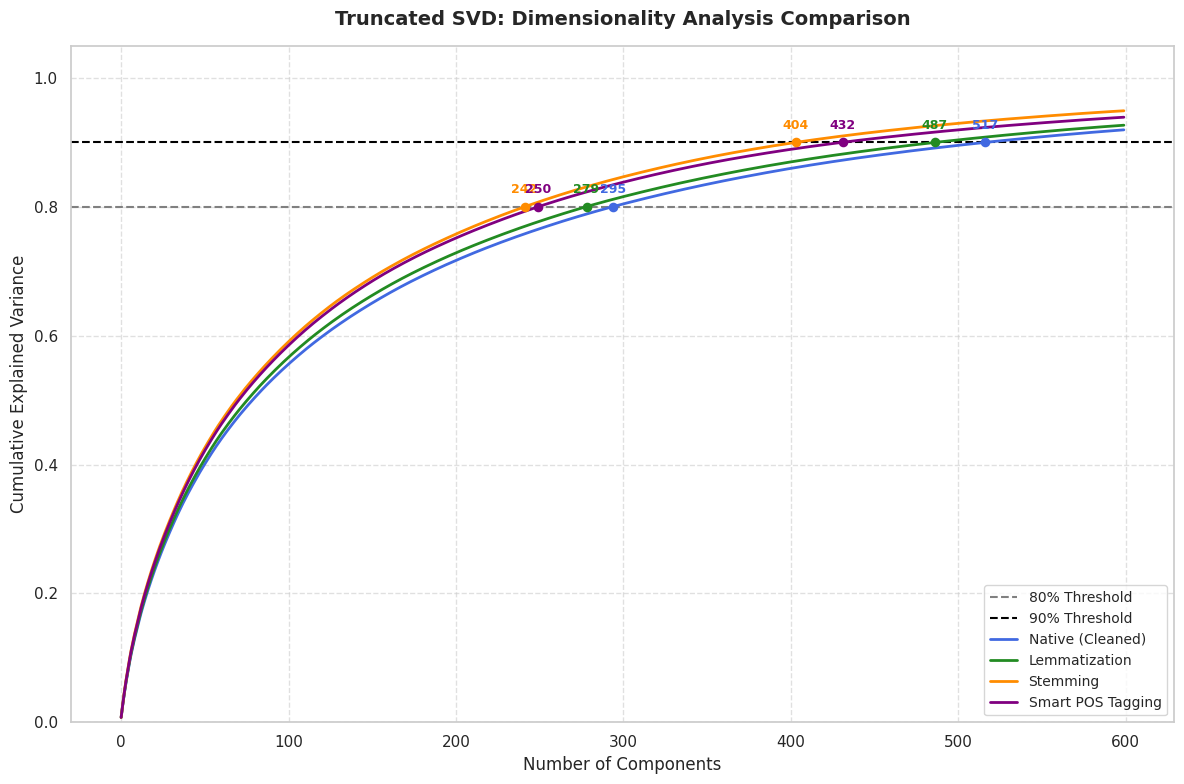

--- Dimensionality Analysis Summary (Truncated SVD) ---
Model: Native (Cleaned)          | 80% Variance: 295 comps | 90% Variance: 517 comps
Model: Lemmatization             | 80% Variance: 279 comps | 90% Variance: 487 comps
Model: Stemming                  | 80% Variance: 242 comps | 90% Variance: 404 comps
Model: Smart POS Tagging         | 80% Variance: 250 comps | 90% Variance: 432 comps


In [ ]:
### 4.1.2 Dimensionality Analysis Comparison across Preprocessing Models

from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Define the 4 preprocessing feature matrices and graph styling
preprocessing_models = [
    {"name": "Native (Cleaned)", "data": X_train_full, "color": "royalblue"},
    {"name": "Lemmatization", "data": X_train_lemmatized, "color": "forestgreen"},
    {"name": "Stemming", "data": X_train_stemmed, "color": "darkorange"},
    {"name": "Smart POS Tagging", "data": X_train_pos, "color": "purple"}
]

n_components = 600

# Set up a single figure
plt.figure(figsize=(12, 8))

results = []

# Horizontal threshold lines for 80% and 90% (plotted once)
plt.axhline(y=0.8, color='gray', linestyle='--', linewidth=1.5, label='80% Threshold')
plt.axhline(y=0.9, color='black', linestyle='--', linewidth=1.5, label='90% Threshold')

for model_info in preprocessing_models:
    name = model_info["name"]
    X_matrix = model_info["data"]
    line_color = model_info["color"]

    # 1. Fit SVD on the model's feature matrix
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    svd.fit(X_matrix)

    # 2. Calculate cumulative explained variance
    cum_var = np.cumsum(svd.explained_variance_ratio_)

    # 3. Identify component count indices for 80% and 90% variance
    idx_80 = np.argmax(cum_var >= 0.8)
    idx_90 = np.argmax(cum_var >= 0.9)

    comp_80 = idx_80 + 1
    comp_90 = idx_90 + 1

    results.append({
        "Model": name,
        "Components 80%": comp_80,
        "Components 90%": comp_90
    })

    # 4. Plot Cumulative Explained Variance curve
    plt.plot(cum_var, label=name, color=line_color, linewidth=2)

    # Highlight intersection points with markers & text annotations
    plt.scatter([idx_80, idx_90], [0.8, 0.9], color=line_color, zorder=5, s=35)

    # Annotations adjusted to use the line color for clarity on a shared graph
    plt.annotate(f"{comp_80}", (idx_80, 0.8), textcoords="offset points", xytext=(0, 10),
                 color=line_color, fontweight='bold', fontsize=9, ha='center')
    plt.annotate(f"{comp_90}", (idx_90, 0.9), textcoords="offset points", xytext=(0, 10),
                 color=line_color, fontweight='bold', fontsize=9, ha='center')

# Chart styling
plt.title('Truncated SVD: Dimensionality Analysis Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary table of components required
print("--- Dimensionality Analysis Summary (Truncated SVD) ---")
for res in results:
    print(f"Model: {res['Model']:<25} | 80% Variance: {res['Components 80%']:3d} comps | 90% Variance: {res['Components 90%']:3d} comps")

### 4.1.3 LogReg on SVD

Training Logistic Regression models on 90% SVD features...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


--- Logistic Regression Accuracy Comparison ---
            Preprocessing Approach  Original (Full TF-IDF)  90% SVD Truncated
 Native (Cleaned)\n(SVD: 517 dims)                0.874512           0.866060
    Lemmatization\n(SVD: 487 dims)                0.874187           0.868336
         Stemming\n(SVD: 404 dims)                0.881664           0.872887
Smart POS Tagging\n(SVD: 432 dims)                0.880039           0.873212


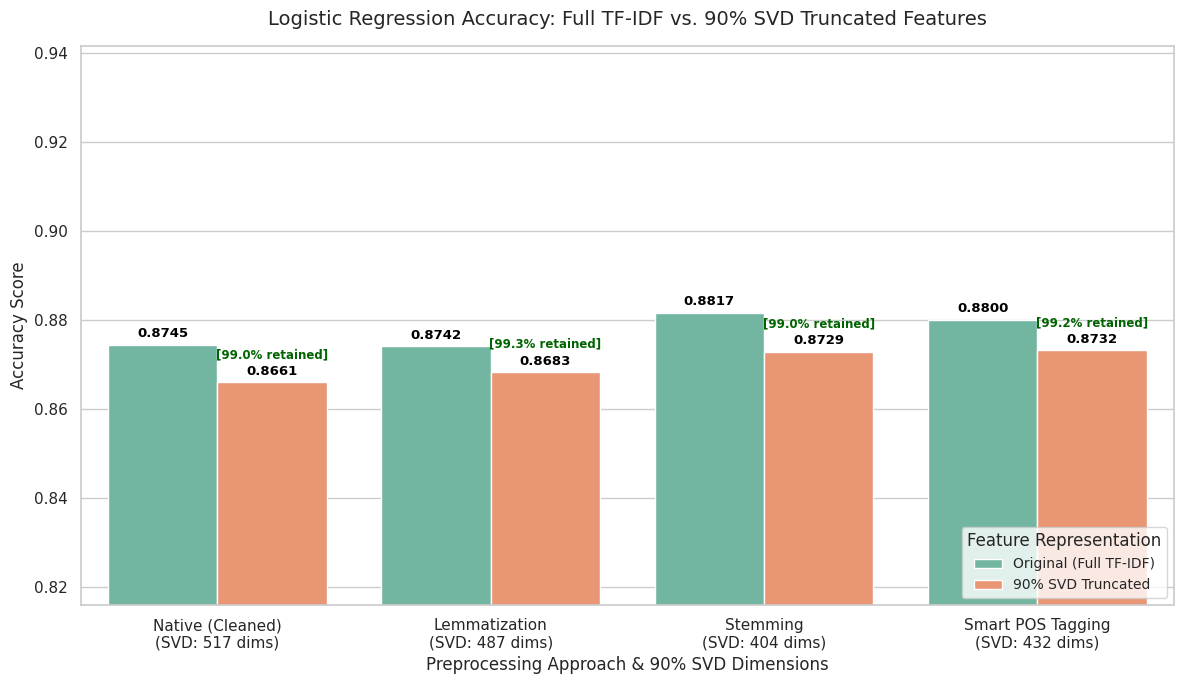

In [ ]:
"""### 4.1.3 Accuracy Comparison: Original vs 90% SVD Features (Logistic Regression)"""

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurations for the 4 preprocessing models: (Name, X_train, X_test, Original_Accuracy)
models_config = [
    ("Native (Cleaned)", X_train_full, X_test_full, accuracy),
    ("Lemmatization", X_train_lemmatized, X_test_lemmatized, accuracy_lem),
    ("Stemming", X_train_stemmed, X_test_stemmed, accuracy_stem),
    ("Smart POS Tagging", X_train_pos, X_test_pos, accuracy_pos)
]

comparison_records = []

print("Training Logistic Regression models on 90% SVD features...")

for name, X_tr, X_te, full_acc in models_config:
    # 1. Identify component count for 90% cumulative variance
    svd_temp = TruncatedSVD(n_components=600, random_state=42)
    svd_temp.fit(X_tr)
    n_comp_90 = np.argmax(np.cumsum(svd_temp.explained_variance_ratio_) >= 0.9) + 1

    # 2. Fit SVD transformation with 90% components
    svd_90 = TruncatedSVD(n_components=n_comp_90, random_state=42)
    X_tr_svd = svd_90.fit_transform(X_tr)
    X_te_svd = svd_90.transform(X_te)

    # 3. Train Logistic Regression on reduced SVD features
    clf_svd = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
    clf_svd.fit(X_tr_svd, train_df['label'])

    # 4. Predict on reduced test set and calculate accuracy
    preds_svd = clf_svd.predict(X_te_svd)
    svd_acc = accuracy_score(test_df['label'], preds_svd)

    comparison_records.append({
        "Preprocessing Approach": f"{name}\n(SVD: {n_comp_90} dims)",
        "Original (Full TF-IDF)": full_acc,
        "90% SVD Truncated": svd_acc
    })

# Convert comparison to DataFrame
df_comp = pd.DataFrame(comparison_records)

print("\n--- Logistic Regression Accuracy Comparison ---")
print(df_comp.to_string(index=False))

# Melt DataFrame for standardized paired bar plot
df_comp_melted = df_comp.melt(
    id_vars="Preprocessing Approach",
    var_name="Representation",
    value_name="Accuracy"
)

# Plotting the side-by-side bar chart
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_comp_melted,
    x="Preprocessing Approach",
    y="Accuracy",
    hue="Representation",
    palette="Set2"
)

# Expand upper Y-limit so annotations fit comfortably
min_score = df_comp_melted["Accuracy"].min()
plt.ylim(max(0, min_score - 0.05), min(1.05, df_comp_melted["Accuracy"].max() + 0.06))

plt.title("Logistic Regression Accuracy: Full TF-IDF vs. 90% SVD Truncated Features", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Preprocessing Approach & 90% SVD Dimensions", fontsize=12)
plt.legend(title="Feature Representation", loc="lower right", fontsize=10)

# Annotate bars (Patches 0..3 are Original, Patches 4..7 are 90% SVD)
n_models = len(models_config)
for i in range(n_models):
    # 1. Original Bar Annotation (BLACK)
    p_orig = ax.patches[i]
    h_orig = p_orig.get_height()
    if h_orig > 0:
        ax.annotate(f"{h_orig:.4f}",
                    (p_orig.get_x() + p_orig.get_width() / 2., h_orig),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9.5, fontweight='bold', color='black')

    # 2. 90% SVD Bar Annotations: Score in BLACK, Retained % in DARK GREEN
    p_svd = ax.patches[i + n_models]
    h_svd = p_svd.get_height()
    if h_svd > 0:
        retention = (h_svd / h_orig) * 100

        # SVD Accuracy Score (BLACK)
        ax.annotate(f"{h_svd:.4f}",
                    (p_svd.get_x() + p_svd.get_width() / 2., h_svd),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9.5, fontweight='bold', color='black')

        # Retained Percentage (DARK GREEN)
        ax.annotate(f"[{retention:.1f}% retained]",
                    (p_svd.get_x() + p_svd.get_width() / 2., h_svd),
                    ha='center', va='center',
                    xytext=(0, 20),
                    textcoords='offset points',
                    fontsize=8.5, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

### 4.1.3.5 80 vs 90 percent

Training Logistic Regression models on 90% and 80% SVD features...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


--- Logistic Regression Accuracy Comparison ---
                     Preprocessing Approach  Original (Full TF-IDF)  90% SVD Truncated  80% SVD Truncated
 Native (Cleaned)\n(SVD 90%: 517, 80%: 295)                0.874512           0.866060           0.850780
    Lemmatization\n(SVD 90%: 487, 80%: 279)                0.874187           0.868336           0.852731
         Stemming\n(SVD 90%: 404, 80%: 242)                0.881664           0.872887           0.860208
Smart POS Tagging\n(SVD 90%: 432, 80%: 250)                0.880039           0.873212           0.858257


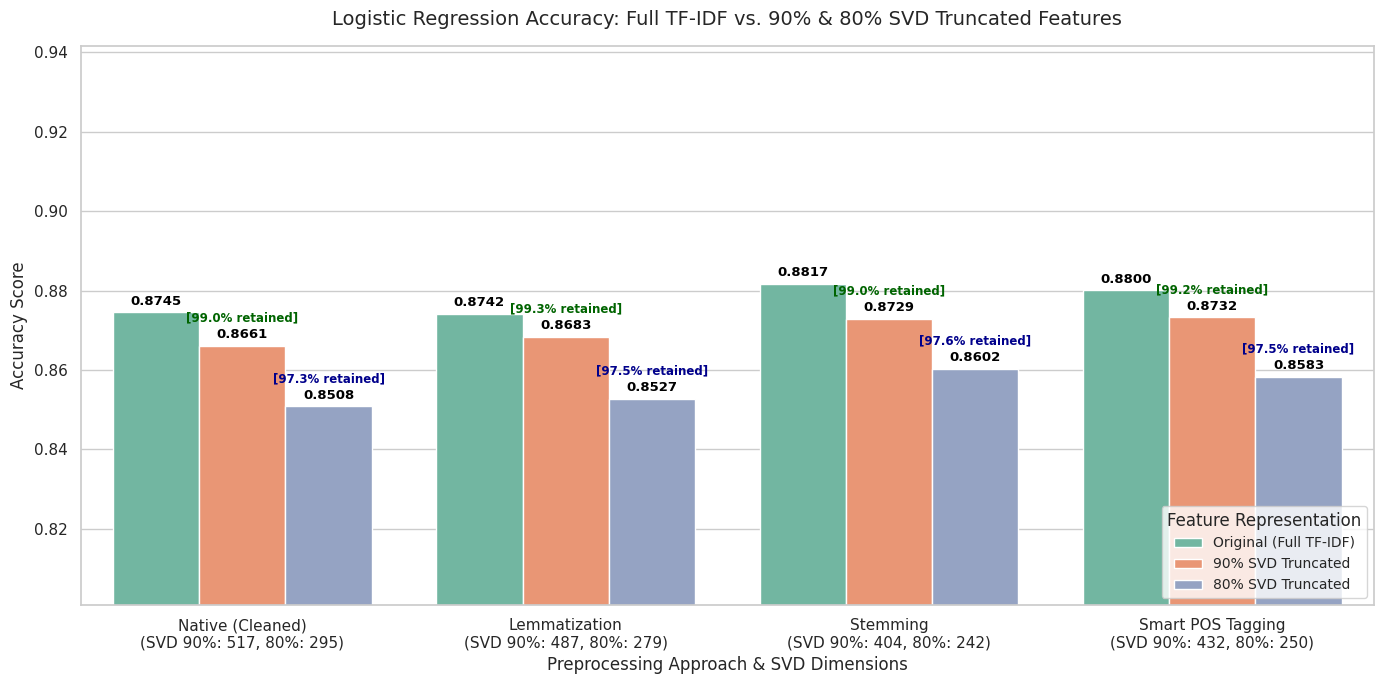

In [ ]:
### 4.1.3 Accuracy Comparison: Original vs 90% & 80% SVD Features (Logistic Regression)

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurations for the 4 preprocessing models: (Name, X_train, X_test, Original_Accuracy)
# models_config = [...]

comparison_records = []

print("Training Logistic Regression models on 90% and 80% SVD features...")

for name, X_tr, X_te, full_acc in models_config:
    # 1. Identify component count for 90% and 80% cumulative variance
    svd_temp = TruncatedSVD(n_components=600, random_state=42)
    svd_temp.fit(X_tr)
    n_comp_90 = np.argmax(np.cumsum(svd_temp.explained_variance_ratio_) >= 0.9) + 1
    n_comp_80 = np.argmax(np.cumsum(svd_temp.explained_variance_ratio_) >= 0.8) + 1

    # 2. Fit SVD transformation and train for 90%
    svd_90 = TruncatedSVD(n_components=n_comp_90, random_state=42)
    X_tr_svd_90 = svd_90.fit_transform(X_tr)
    X_te_svd_90 = svd_90.transform(X_te)

    clf_svd_90 = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
    clf_svd_90.fit(X_tr_svd_90, train_df['label'])
    preds_svd_90 = clf_svd_90.predict(X_te_svd_90)
    svd_acc_90 = accuracy_score(test_df['label'], preds_svd_90)

    # 3. Fit SVD transformation and train for 80%
    svd_80 = TruncatedSVD(n_components=n_comp_80, random_state=42)
    X_tr_svd_80 = svd_80.fit_transform(X_tr)
    X_te_svd_80 = svd_80.transform(X_te)

    clf_svd_80 = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
    clf_svd_80.fit(X_tr_svd_80, train_df['label'])
    preds_svd_80 = clf_svd_80.predict(X_te_svd_80)
    svd_acc_80 = accuracy_score(test_df['label'], preds_svd_80)

    comparison_records.append({
        "Preprocessing Approach": f"{name}\n(SVD 90%: {n_comp_90}, 80%: {n_comp_80})",
        "Original (Full TF-IDF)": full_acc,
        "90% SVD Truncated": svd_acc_90,
        "80% SVD Truncated": svd_acc_80
    })

# Convert comparison to DataFrame
df_comp = pd.DataFrame(comparison_records)

print("\n--- Logistic Regression Accuracy Comparison ---")
print(df_comp.to_string(index=False))

# Melt DataFrame for standardized paired bar plot
df_comp_melted = df_comp.melt(
    id_vars="Preprocessing Approach",
    var_name="Representation",
    value_name="Accuracy"
)

# Plotting the side-by-side bar chart
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_comp_melted,
    x="Preprocessing Approach",
    y="Accuracy",
    hue="Representation",
    palette="Set2"
)

# Expand upper Y-limit so annotations fit comfortably
min_score = df_comp_melted["Accuracy"].min()
plt.ylim(max(0, min_score - 0.05), min(1.05, df_comp_melted["Accuracy"].max() + 0.06))

plt.title("Logistic Regression Accuracy: Full TF-IDF vs. 90% & 80% SVD Truncated Features", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Preprocessing Approach & SVD Dimensions", fontsize=12)
plt.legend(title="Feature Representation", loc="lower right", fontsize=10)

# Annotate bars
n_models = len(models_config)
for i in range(n_models):
    # 1. Original Bar Annotation (BLACK)
    p_orig = ax.patches[i]
    h_orig = p_orig.get_height()
    if h_orig > 0:
        ax.annotate(f"{h_orig:.4f}",
                    (p_orig.get_x() + p_orig.get_width() / 2., h_orig),
                    ha='center', va='center',
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=9.5, fontweight='bold', color='black')

    # 2. 90% SVD Bar Annotations
    p_svd_90 = ax.patches[i + n_models]
    h_svd_90 = p_svd_90.get_height()
    if h_svd_90 > 0:
        retention_90 = (h_svd_90 / h_orig) * 100
        ax.annotate(f"{h_svd_90:.4f}",
                    (p_svd_90.get_x() + p_svd_90.get_width() / 2., h_svd_90),
                    ha='center', va='center', xytext=(0, 8),
                    textcoords='offset points', fontsize=9.5, fontweight='bold', color='black')
        ax.annotate(f"[{retention_90:.1f}% retained]",
                    (p_svd_90.get_x() + p_svd_90.get_width() / 2., h_svd_90),
                    ha='center', va='center', xytext=(0, 20),
                    textcoords='offset points', fontsize=8.5, fontweight='bold', color='darkgreen')

    # 3. 80% SVD Bar Annotations
    p_svd_80 = ax.patches[i + 2 * n_models]
    h_svd_80 = p_svd_80.get_height()
    if h_svd_80 > 0:
        retention_80 = (h_svd_80 / h_orig) * 100
        ax.annotate(f"{h_svd_80:.4f}",
                    (p_svd_80.get_x() + p_svd_80.get_width() / 2., h_svd_80),
                    ha='center', va='center', xytext=(0, 8),
                    textcoords='offset points', fontsize=9.5, fontweight='bold', color='black')
        ax.annotate(f"[{retention_80:.1f}% retained]",
                    (p_svd_80.get_x() + p_svd_80.get_width() / 2., h_svd_80),
                    ha='center', va='center', xytext=(0, 20),
                    textcoords='offset points', fontsize=8.5, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

### 4.1.4 try plot

Training Logistic Regression models on 90% SVD features...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


--- Logistic Regression Accuracy Comparison ---
            Preprocessing Approach  Original (Full TF-IDF)  90% SVD Truncated
 Native (Cleaned)\n(SVD: 517 dims)                0.874512           0.866060
    Lemmatization\n(SVD: 487 dims)                0.874187           0.868336
         Stemming\n(SVD: 404 dims)                0.881664           0.872887
Smart POS Tagging\n(SVD: 432 dims)                0.880039           0.873212


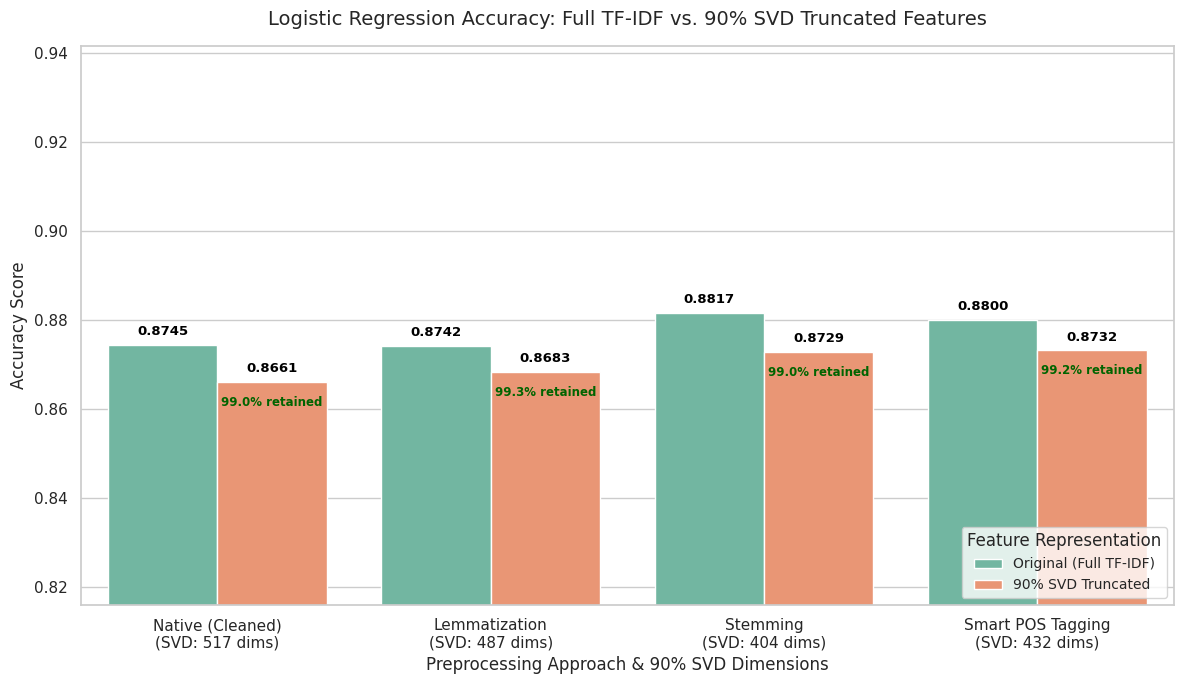

In [ ]:
"""### 4.1.3 Accuracy Comparison: Original vs 90% SVD Features (Logistic Regression)"""

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurations for the 4 preprocessing models: (Name, X_train, X_test, Original_Accuracy)
models_config = [
    ("Native (Cleaned)", X_train_full, X_test_full, accuracy),
    ("Lemmatization", X_train_lemmatized, X_test_lemmatized, accuracy_lem),
    ("Stemming", X_train_stemmed, X_test_stemmed, accuracy_stem),
    ("Smart POS Tagging", X_train_pos, X_test_pos, accuracy_pos)
]

comparison_records = []

print("Training Logistic Regression models on 90% SVD features...")

for name, X_tr, X_te, full_acc in models_config:
    # 1. Identify component count for 90% cumulative variance
    svd_temp = TruncatedSVD(n_components=600, random_state=42)
    svd_temp.fit(X_tr)
    n_comp_90 = np.argmax(np.cumsum(svd_temp.explained_variance_ratio_) >= 0.9) + 1

    # 2. Fit SVD transformation with 90% components
    svd_90 = TruncatedSVD(n_components=n_comp_90, random_state=42)
    X_tr_svd = svd_90.fit_transform(X_tr)
    X_te_svd = svd_90.transform(X_te)

    # 3. Train Logistic Regression on reduced SVD features
    clf_svd = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
    clf_svd.fit(X_tr_svd, train_df['label'])

    # 4. Predict on reduced test set and calculate accuracy
    preds_svd = clf_svd.predict(X_te_svd)
    svd_acc = accuracy_score(test_df['label'], preds_svd)

    comparison_records.append({
        "Preprocessing Approach": f"{name}\n(SVD: {n_comp_90} dims)",
        "Original (Full TF-IDF)": full_acc,
        "90% SVD Truncated": svd_acc
    })

# Convert comparison to DataFrame
df_comp = pd.DataFrame(comparison_records)

print("\n--- Logistic Regression Accuracy Comparison ---")
print(df_comp.to_string(index=False))

# Melt DataFrame for standardized paired bar plot
df_comp_melted = df_comp.melt(
    id_vars="Preprocessing Approach",
    var_name="Representation",
    value_name="Accuracy"
)

# Plotting the side-by-side bar chart
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_comp_melted,
    x="Preprocessing Approach",
    y="Accuracy",
    hue="Representation",
    palette="Set2"
)

# Expand upper Y-limit so annotations fit comfortably
min_score = df_comp_melted["Accuracy"].min()
plt.ylim(max(0, min_score - 0.05), min(1.05, df_comp_melted["Accuracy"].max() + 0.06))

plt.title("Logistic Regression Accuracy: Full TF-IDF vs. 90% SVD Truncated Features", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Preprocessing Approach & 90% SVD Dimensions", fontsize=12)
plt.legend(title="Feature Representation", loc="lower right", fontsize=10)

# Annotate bars (Patches 0..3 are Original, Patches 4..7 are 90% SVD)
n_models = len(models_config)
for i in range(n_models):
    # 1. Original Bar Annotation (BLACK)
    p_orig = ax.patches[i]
    h_orig = p_orig.get_height()
    if h_orig > 0:
        ax.annotate(f"{h_orig:.4f}",
                    (p_orig.get_x() + p_orig.get_width() / 2., h_orig),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=9.5, fontweight='bold', color='black')

    # 2. 90% SVD Bar Annotations: Score in BLACK, Retained % in DARK GREEN inside the bar
    p_svd = ax.patches[i + n_models]
    h_svd = p_svd.get_height()
    if h_svd > 0:
        retention = (h_svd / h_orig) * 100

        # SVD Accuracy Score (BLACK) - Above the bar
        ax.annotate(f"{h_svd:.4f}",
                    (p_svd.get_x() + p_svd.get_width() / 2., h_svd),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=9.5, fontweight='bold', color='black')

        # Retained Percentage (DARK GREEN) - Inside the bar
        ax.annotate(f"{retention:.1f}% retained",
                    (p_svd.get_x() + p_svd.get_width() / 2., h_svd),
                    ha='center', va='top',
                    xytext=(0, -10),
                    textcoords='offset points',
                    fontsize=8.5, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

## 4.2 Dense Embeddings (Sentence Transformers)

In [ ]:
## 4.2 Dense Embeddings (Sentence Transformers)
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load the Sentence-Transformer model
print("Loading model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Encode train and test sets to Dense Embeddings
print("Generating dense embeddings")
X_train_dense = model.encode(train_df['text'].tolist())
X_test_dense = model.encode(test_df['text'].tolist())

print(f"Dense embeddings shape: {X_train_dense.shape}")

# 3. Train and Evaluate Logistic Regression on Dense Embeddings
clf_dense = LogisticRegression(max_iter=2000, multi_class='multinomial')
clf_dense.fit(X_train_dense, train_df['label'])

preds_dense = clf_dense.predict(X_test_dense)
acc_dense = accuracy_score(test_df['label'], preds_dense)

print(f"\nLogistic Regression Accuracy on Dense Embeddings: {acc_dense:.4f}")

Loading model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating dense embeddings
Dense embeddings shape: (9993, 384)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Accuracy on Dense Embeddings: 0.9083


### 4.2.5 compare embedding

Loading SentenceTransformer model ('all-MiniLM-L6-v2')...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Generating embeddings and evaluating classifiers across preprocessing techniques...
Encoding text for: Native (Cleaned)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Encoding text for: Lemmatization...


...

Encoding text for: Stemming...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Encoding text for: Smart POS Tagging...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Dense Embeddings Accuracy Comparison ---
Preprocessing Approach Logistic Regression Perceptron Winnow
      Native (Cleaned)              0.9034     0.8908 0.8748
         Lemmatization              0.9077     0.8898 0.8784
              Stemming              0.8820     0.8706 0.8407
     Smart POS Tagging              0.9080     0.8904 0.8735


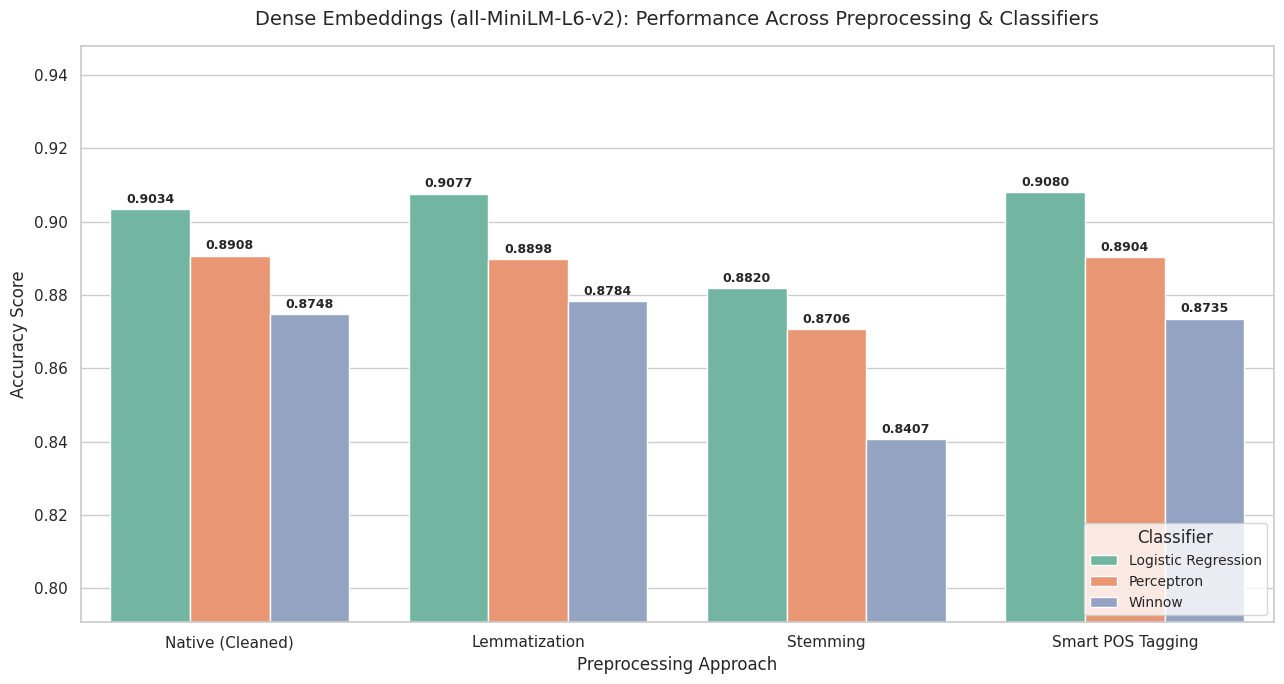

In [ ]:
"""## 4.2 Dense Embeddings (Sentence Transformers) across Preprocessing Methods & Classifiers"""

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Sentence-Transformer model
print("Loading SentenceTransformer model ('all-MiniLM-L6-v2')...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Define the 4 text preprocessing columns to encode
text_sources = [
    ("Native (Cleaned)", "clean_text"),
    ("Lemmatization", "lemmatized_text"),
    ("Stemming", "stemmed_text"),
    ("Smart POS Tagging", "smart_pos_text")
]

dense_results = []

print("\nGenerating embeddings and evaluating classifiers across preprocessing techniques...")

for prep_name, text_col in text_sources:
    print(f"Encoding text for: {prep_name}...")

    # Generate dense embeddings for Train and Test sets
    X_tr_emb = model.encode(train_df[text_col].tolist(), show_progress_bar=False)
    X_te_emb = model.encode(test_df[text_col].tolist(), show_progress_bar=False)

    # --- Classifier 1: Logistic Regression ---
    clf_logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
    clf_logreg.fit(X_tr_emb, train_df['label'])
    acc_logreg = accuracy_score(test_df['label'], clf_logreg.predict(X_te_emb))

    # --- Classifier 2: Perceptron ---
    clf_perc = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
    clf_perc.fit(X_tr_emb, train_df['label'])
    acc_perc = accuracy_score(test_df['label'], clf_perc.predict(X_te_emb))

    # --- Classifier 3: Winnow (SGD Approximation) ---
    clf_winnow = SGDClassifier(loss='log_loss', penalty='l1', alpha=0.0001, learning_rate='constant', eta0=0.1, random_state=42)
    clf_winnow.fit(X_tr_emb, train_df['label'])
    acc_winnow = accuracy_score(test_df['label'], clf_winnow.predict(X_te_emb))

    # Store evaluated accuracies
    dense_results.append({
        "Preprocessing Approach": prep_name,
        "Logistic Regression": acc_logreg,
        "Perceptron": acc_perc,
        "Winnow": acc_winnow
    })

# Convert results to DataFrame
df_dense_results = pd.DataFrame(dense_results)

print("\n--- Dense Embeddings Accuracy Comparison ---")
print(df_dense_results.to_string(index=False, formatters={
    'Logistic Regression': '{:,.4f}'.format,
    'Perceptron': '{:,.4f}'.format,
    'Winnow': '{:,.4f}'.format
}))

# Melt DataFrame for grouped multi-bar plot
df_dense_melted = df_dense_results.melt(
    id_vars="Preprocessing Approach",
    var_name="Classifier",
    value_name="Accuracy"
)

# Plot overall comparison graph
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_dense_melted,
    x="Preprocessing Approach",
    y="Accuracy",
    hue="Classifier",
    palette="Set2"
)

# Customize Y-axis scaling and titles
min_score = df_dense_melted["Accuracy"].min()
plt.ylim(max(0, min_score - 0.05), min(1.0, df_dense_melted["Accuracy"].max() + 0.04))

plt.title("Dense Embeddings (all-MiniLM-L6-v2): Performance Across Preprocessing & Classifiers", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Preprocessing Approach", fontsize=12)
plt.legend(title="Classifier", loc="lower right", fontsize=10)

# Annotate exact accuracy scores on top of each bar
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.4f}",
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center',
                    xytext=(0, 7),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2.6 Embedded vs TF-IDF

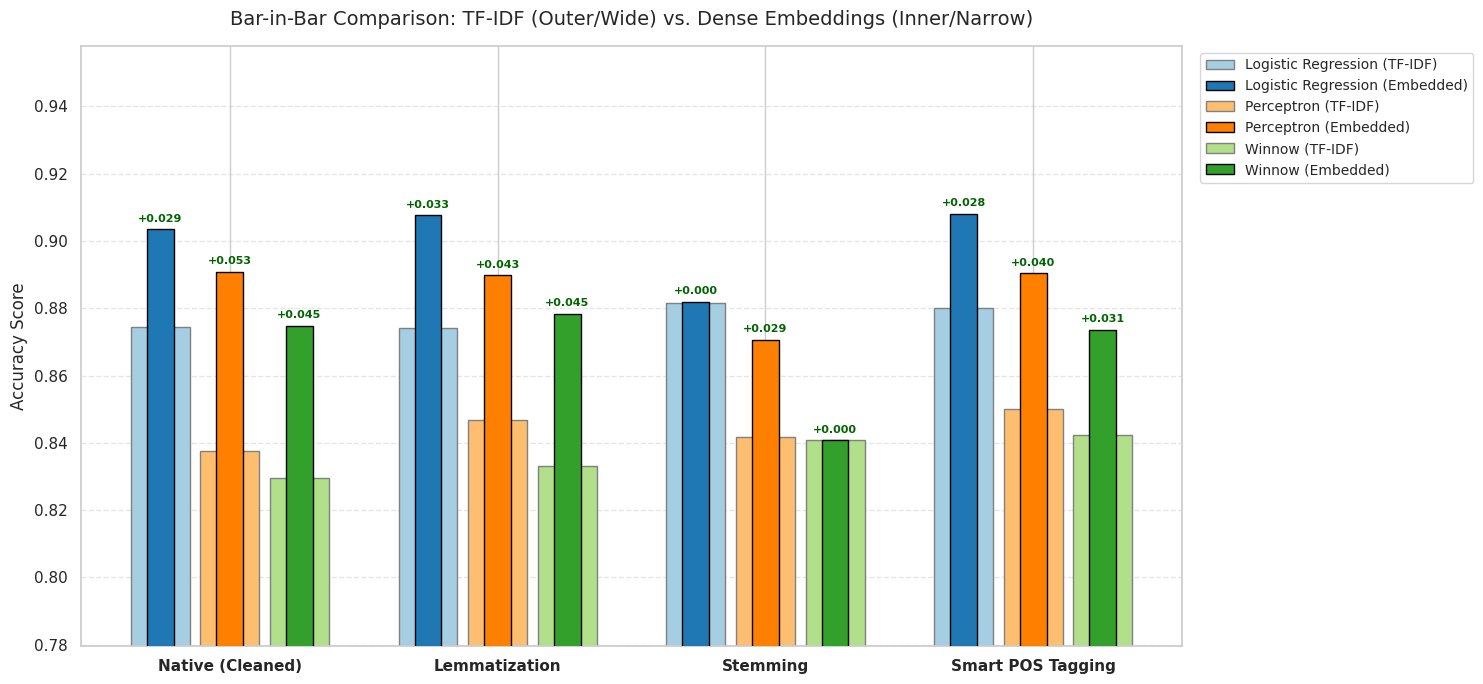

In [ ]:
"""## 4.2.6 Embedded vs. Non-Embedded (TF-IDF) Comparison: Bar-Within-a-Bar Visualization"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Standardize Preprocessing labels and Classifier lists
prep_labels = ["Native (Cleaned)", "Lemmatization", "Stemming", "Smart POS Tagging"]
classifiers = ["Logistic Regression", "Perceptron", "Winnow"]

# Extract 3.4 TF-IDF data from existing df_overall_acc
tfidf_data = {
    "Logistic Regression": df_overall_acc["Logistic Regression"].values,
    "Perceptron": df_overall_acc["Perceptron"].values,
    "Winnow": df_overall_acc["Winnow"].values
}

# Extract 4.2 Dense Embedding data from existing df_dense_results
dense_data = {
    "Logistic Regression": df_dense_results["Logistic Regression"].values,
    "Perceptron": df_dense_results["Perceptron"].values,
    "Winnow": df_dense_results["Winnow"].values
}

# Distinct outer (TF-IDF) and inner (Dense) colors for each classifier
classifier_colors = {
    "Logistic Regression": {"outer": "#a6cee3", "inner": "#1f78b4"},   # Light Blue / Dark Blue
    "Perceptron":          {"outer": "#fdbf6f", "inner": "#ff7f00"},   # Light Orange / Dark Orange
    "Winnow":              {"outer": "#b2df8a", "inner": "#33a02c"}    # Light Green / Dark Green
}

x = np.arange(len(prep_labels))  # 4 preprocessing groups
group_offsets = [-0.26, 0, 0.26] # Offsets for the 3 classifiers
outer_width = 0.22               # Wide outer bar
inner_width = 0.10               # Centered narrow inner bar

fig, ax = plt.subplots(figsize=(15, 7))

for c_idx, clf_name in enumerate(classifiers):
    offset = group_offsets[c_idx]
    c_outer = classifier_colors[clf_name]["outer"]
    c_inner = classifier_colors[clf_name]["inner"]

    # 1. Outer Bar: TF-IDF (Non-Embedded)
    ax.bar(
        x + offset,
        tfidf_data[clf_name],
        width=outer_width,
        color=c_outer,
        edgecolor='gray',
        linewidth=1,
        zorder=2,
        label=f"{clf_name} (TF-IDF)"
    )

    # 2. Inner Bar: Dense Embedding (Nested inside outer bar)
    ax.bar(
        x + offset,
        dense_data[clf_name],
        width=inner_width,
        color=c_inner,
        edgecolor='black',
        linewidth=1,
        zorder=3,
        label=f"{clf_name} (Embedded)"
    )

    # 3. Add Delta Annotations above each inner/outer pair
    for i in range(len(prep_labels)):
        x_c = x[i] + offset
        y_tf = tfidf_data[clf_name][i]
        y_dense = dense_data[clf_name][i]

        top_y = max(y_tf, y_dense)
        diff = y_dense - y_tf
        diff_str = f"+{diff:.3f}" if diff >= 0 else f"{diff:.3f}"
        diff_color = "darkgreen" if diff >= 0 else "crimson"

        ax.annotate(
            diff_str,
            (x_c, top_y),
            ha='center', va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=8, fontweight='bold', color=diff_color
        )

# Graph layout formatting
ax.set_xticks(x)
ax.set_xticklabels(prep_labels, fontsize=11, fontweight='bold')
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("Bar-in-Bar Comparison: TF-IDF (Outer/Wide) vs. Dense Embeddings (Inner/Narrow)", fontsize=14, pad=15)

# Calculate Y-axis bounds dynamically
all_vals = list(df_overall_melted["Accuracy"]) + list(df_dense_melted["Accuracy"])
min_val, max_val = min(all_vals), max(all_vals)
ax.set_ylim(max(0, min_val - 0.05), min(1.0, max_val + 0.05))

ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 4.3 Intent Visualization (2D Projection)


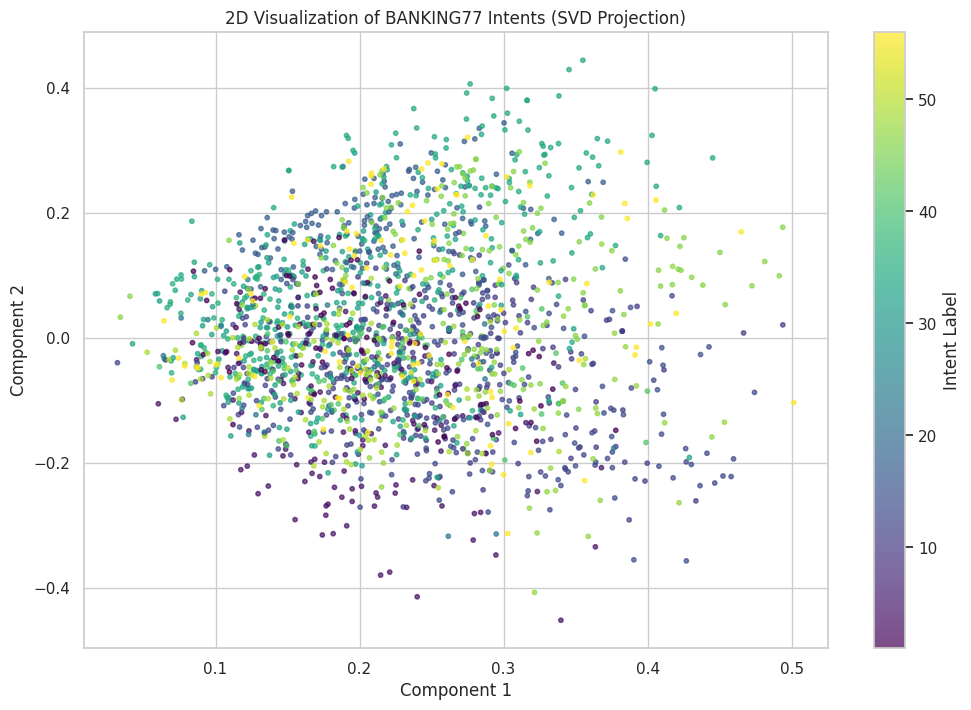

In [ ]:
## 4.3 Intent Visualization (2D Projection)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# 1. Project the data to 2D
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_train_2d = svd_2d.fit_transform(X_train_full)

# 2. Visualize
plt.figure(figsize=(12, 8))
# We plot a sample (e.g., 2000 samples) so the plot isn't too crowded
sample_size = 2000
scatter = plt.scatter(X_train_2d[:sample_size, 0],
                      X_train_2d[:sample_size, 1],
                      c=train_df['label'][:sample_size],
                      cmap='viridis', s=10, alpha=0.7)

plt.colorbar(scatter, label='Intent Label')
plt.title('2D Visualization of BANKING77 Intents (SVD Projection)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

# Step 5: Error Analysis & Model Interpretation

## 5.1 Confusion Matrix Focus: Identifying Top Confusion Pairs

In [ ]:
## 5.1 Confusion Matrix Focus: Identifying Top Confusion Pairs

from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Generate Confusion Matrix
# We use the test set predictions
cm = confusion_matrix(test_df['label'], y_pred)

# 2. Extract label names from the dataset feature mapping
# This assumes you are using the 'dataset' object from Hugging Face
# label_names = dataset['train'].features['label'].names
# 2. Extract label names directly from the DataFrame
label_map = train_df.set_index('label')['label_text'].drop_duplicates().sort_index().to_dict()
label_names = [label_map[i] for i in sorted(label_map.keys())]

# 3. Clear diagonal to focus strictly on errors
np.fill_diagonal(cm, 0)

# 4. Identify the indices of the 10 most frequent error pairs
# ravel() flattens the matrix, argsort() sorts by count
error_indices = np.unravel_index(np.argsort(cm.ravel())[-10:], cm.shape)

print("--- Top 10 Confusion Pairs (Error Analysis) ---")

# Store errors for display
sorted_errors = []
for i in range(10):
    r, c = error_indices[0][i], error_indices[1][i]
    sorted_errors.append((cm[r, c], r, c))

# Sort by count (descending)
sorted_errors.sort(key=lambda x: x[0], reverse=True)

# Print results with clear labels
for count, true_idx, pred_idx in sorted_errors:
    print(f"True Intent: {true_idx:2d} ({label_names[true_idx]:<25}) | "
          f"Predicted: {pred_idx:2d} ({label_names[pred_idx]:<25}) | "
          f"Count: {count}")

--- Top 10 Confusion Pairs (Error Analysis) ---
True Intent: 72 (virtual_card_not_working ) | Predicted: 37 (get_disposable_virtual_card) | Count: 10
True Intent: 74 (why_verify_identity      ) | Predicted: 69 (verify_my_identity       ) | Count: 6
True Intent: 48 (pending_transfer         ) | Predicted:  5 (balance_not_updated_after_bank_transfer) | Count: 5
True Intent: 72 (virtual_card_not_working ) | Predicted: 40 (getting_virtual_card     ) | Count: 5
True Intent:  5 (balance_not_updated_after_bank_transfer) | Predicted: 66 (transfer_not_received_by_recipient) | Count: 5
True Intent: 48 (pending_transfer         ) | Predicted: 67 (transfer_timing          ) | Count: 4
True Intent: 11 (card_arrival             ) | Predicted: 12 (card_delivery_estimate   ) | Count: 4
True Intent: 21 (change_pin               ) | Predicted: 38 (get_physical_card        ) | Count: 4
True Intent: 16 (card_payment_not_recognised) | Predicted: 34 (extra_charge_on_statement) | Count: 4
True Intent: 36 (fi

### 5.1.1 improved Confusion Pairs

--- Step 5.1: Explicit Retraining & Confusion Analysis on Smart POS Tagging ---
1/3 Training Baseline Logistic Regression (Full TF-IDF POS)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


2/3 Performing SVD (90% variance) and Training SVD Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


    SVD Reduced Dimensions: 432 components
3/3 Generating Dense Embeddings for POS Text & Training Embedding Logistic Regression...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



================ TOP 10 CONFUSION PAIRS COMPARISON ================

--- Baseline (TF-IDF POS) ---
                            True Intent                        Predicted Intent  Error Count
               virtual_card_not_working             get_disposable_virtual_card            9
                    why_verify_identity                      verify_my_identity            7
                            pin_blocked                       get_physical_card            5
                     verify_my_identity                     why_verify_identity            5
                           card_arrival                  card_delivery_estimate            5
                  fiat_currency_support                        exchange_via_app            5
               virtual_card_not_working                        card_not_working            5
                       pending_transfer                         transfer_timing            5
balance_not_updated_after_bank_transfer      transfer_not_recei

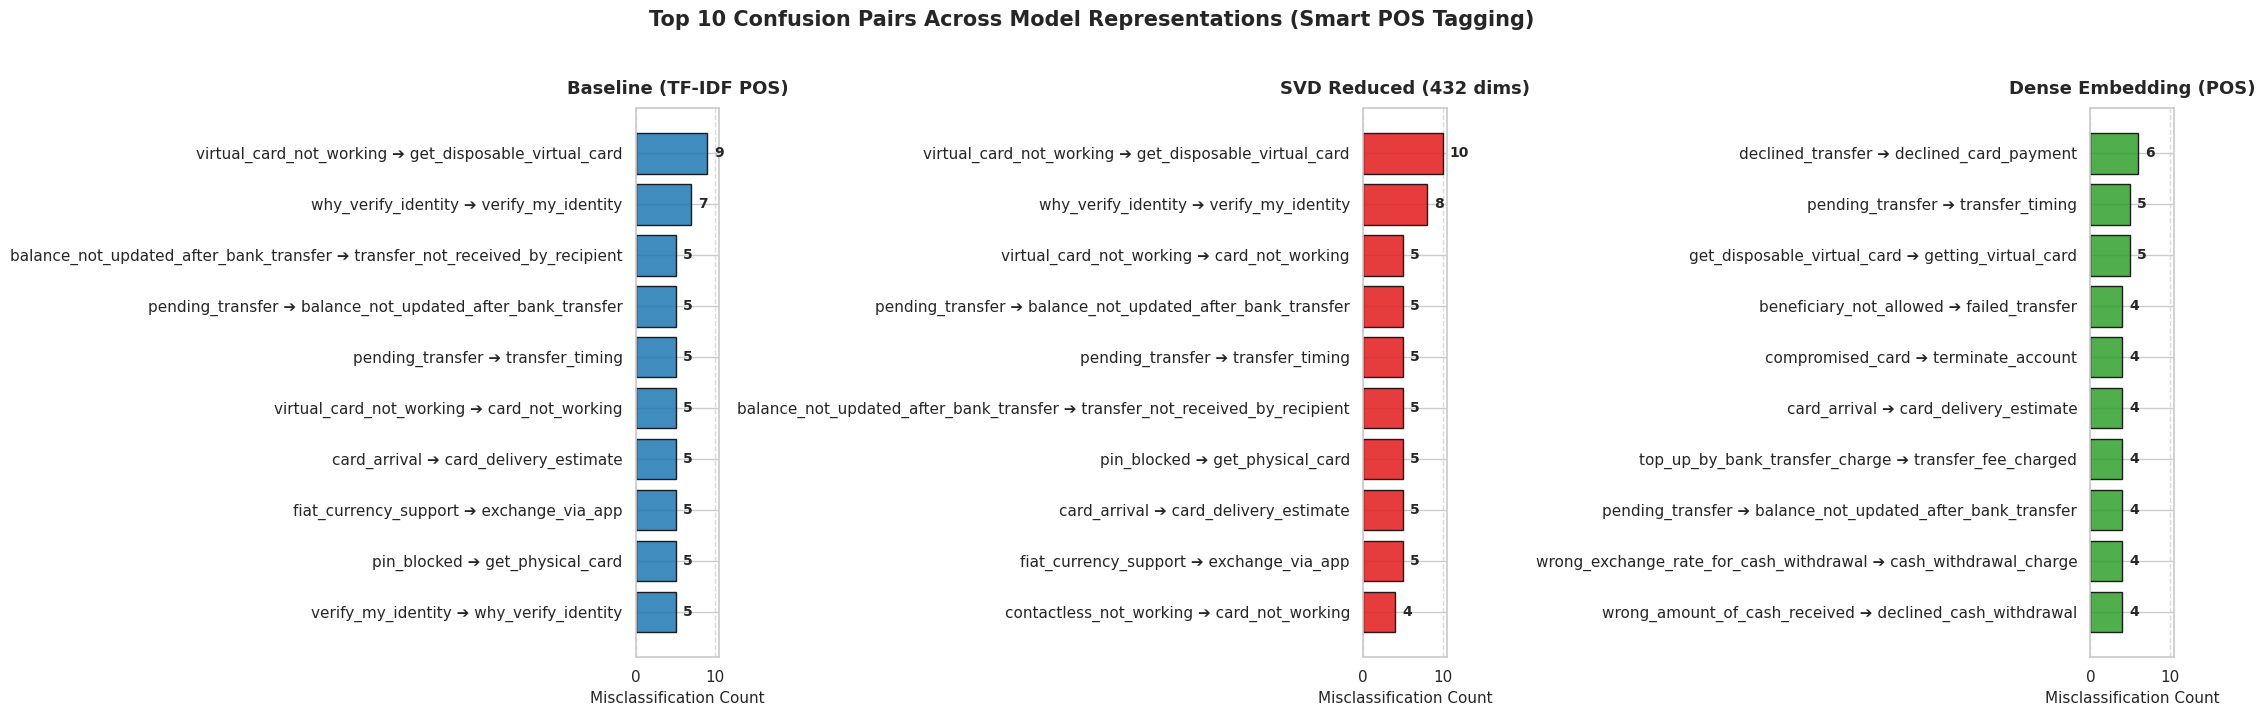


--- Error Pattern Continuity Analysis ---
1. Overlap (Baseline vs SVD): 9/10 identical top confusion pairs
2. Overlap (Baseline vs Embedding): 3/10 identical top confusion pairs
3. New confusion pairs introduced by SVD: {'contactless_not_working ➔ card_not_working'}
4. Confusion pairs resolved/modified by Embedding: {'virtual_card_not_working ➔ get_disposable_virtual_card', 'why_verify_identity ➔ verify_my_identity', 'balance_not_updated_after_bank_transfer ➔ transfer_not_received_by_recipient', 'pin_blocked ➔ get_physical_card', 'fiat_currency_support ➔ exchange_via_app', 'virtual_card_not_working ➔ card_not_working', 'verify_my_identity ➔ why_verify_identity'}


In [ ]:
## 5.1 Confusion Matrix Focus: Identifying Top Confusion Pairs Across Models (Self-Contained & Explicit Retraining)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sentence_transformers import SentenceTransformer

# ---------------------------------------------------------
# 1. Extraction Helper Function
# ---------------------------------------------------------
def get_top_confusion_pairs(y_true, y_pred, label_names, model_name, top_n=10):
    cm = confusion_matrix(y_true, y_pred)
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0) # Clear diagonal to focus strictly on misclassifications

    # Identify indices of top N errors
    flat_indices = np.argsort(cm_no_diag.ravel())[-top_n:][::-1]
    rows, cols = np.unravel_index(flat_indices, cm_no_diag.shape)

    records = []
    for r, c in zip(rows, cols):
        records.append({
            'Model': model_name,
            'True Intent': label_names[r],
            'Predicted Intent': label_names[c],
            'Error Pair': f"{label_names[r]} ➔ {label_names[c]}",
            'Error Count': cm_no_diag[r, c]
        })
    return pd.DataFrame(records)

# ---------------------------------------------------------
# 2. Extract Labels & Target Vector
# ---------------------------------------------------------
## label_names = dataset['train'].features['label'].names
# 2. Extract label names directly from the DataFrame
label_map = train_df.set_index('label')['label_text'].drop_duplicates().sort_index().to_dict()
label_names = [label_map[i] for i in sorted(label_map.keys())]
y_train = train_df['label']
y_test = test_df['label']

print("--- Step 5.1: Explicit Retraining & Confusion Analysis on Smart POS Tagging ---")

# ---------------------------------------------------------
# 3. Model A: Baseline (Full TF-IDF POS Tagging + Logistic Regression)
# ---------------------------------------------------------
print("1/3 Training Baseline Logistic Regression (Full TF-IDF POS)...")
clf_baseline = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_baseline.fit(X_train_pos, y_train)
y_pred_baseline = clf_baseline.predict(X_test_pos)

# ---------------------------------------------------------
# 4. Model B: SVD Reduced (TF-IDF POS + SVD 90% Variance + Logistic Regression)
# ---------------------------------------------------------
print("2/3 Performing SVD (90% variance) and Training SVD Logistic Regression...")
# Determine component count for 90% explained variance on POS TF-IDF
svd_temp = TruncatedSVD(n_components=600, random_state=42)
svd_temp.fit(X_train_pos)
n_comp_90_pos = np.argmax(np.cumsum(svd_temp.explained_variance_ratio_) >= 0.9) + 1

# Apply SVD transformation
svd_pos = TruncatedSVD(n_components=n_comp_90_pos, random_state=42)
X_tr_pos_svd = svd_pos.fit_transform(X_train_pos)
X_te_pos_svd = svd_pos.transform(X_test_pos)

clf_svd = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_svd.fit(X_tr_pos_svd, y_train)
y_pred_svd = clf_svd.predict(X_te_pos_svd)
print(f"    SVD Reduced Dimensions: {n_comp_90_pos} components")

# ---------------------------------------------------------
# 5. Model C: Dense Embedding (all-MiniLM-L6-v2 on POS + Logistic Regression)
# ---------------------------------------------------------
print("3/3 Generating Dense Embeddings for POS Text & Training Embedding Logistic Regression...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_tr_pos_emb = embedder.encode(train_df['smart_pos_text'].tolist(), show_progress_bar=False)
X_te_pos_emb = embedder.encode(test_df['smart_pos_text'].tolist(), show_progress_bar=False)

clf_emb = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_emb.fit(X_tr_pos_emb, y_train)
y_pred_emb = clf_emb.predict(X_te_pos_emb)

# ---------------------------------------------------------
# 6. Extract Top 10 Confusion Pairs
# ---------------------------------------------------------
df_err_base = get_top_confusion_pairs(y_test, y_pred_baseline, label_names, "Baseline (TF-IDF POS)")
df_err_svd  = get_top_confusion_pairs(y_test, y_pred_svd, label_names, f"SVD Reduced ({n_comp_90_pos} dims)")
df_err_emb  = get_top_confusion_pairs(y_test, y_pred_emb, label_names, "Dense Embedding (POS)")

df_top_errors_all = pd.concat([df_err_base, df_err_svd, df_err_emb], ignore_index=True)

# ---------------------------------------------------------
# 7. Print Clean Comparison Tables
# ---------------------------------------------------------
print("\n================ TOP 10 CONFUSION PAIRS COMPARISON ================")
models_list = ["Baseline (TF-IDF POS)", f"SVD Reduced ({n_comp_90_pos} dims)", "Dense Embedding (POS)"]
for model_name in models_list:
    print(f"\n--- {model_name} ---")
    sub = df_top_errors_all[df_top_errors_all['Model'] == model_name]
    print(sub[['True Intent', 'Predicted Intent', 'Error Count']].to_string(index=False))

# ---------------------------------------------------------
# 8. Side-by-Side Horizontal Bar Chart Comparison
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True)
colors = ['#1f78b4', '#e31a1c', '#33a02c']

for idx, m_name in enumerate(models_list):
    ax = axes[idx]
    sub_data = df_top_errors_all[df_top_errors_all['Model'] == m_name].sort_values('Error Count', ascending=True)

    ax.barh(sub_data['Error Pair'], sub_data['Error Count'], color=colors[idx], alpha=0.85, edgecolor='black')
    ax.set_title(m_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Misclassification Count", fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    for p in ax.patches:
        w = p.get_width()
        ax.annotate(f"{int(w)}", (w, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.suptitle("Top 10 Confusion Pairs Across Model Representations (Smart POS Tagging)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Pattern Continuity & SVD/Embedding Comparison
# ---------------------------------------------------------
pairs_base = set(df_err_base['Error Pair'])
pairs_svd  = set(df_err_svd['Error Pair'])
pairs_emb  = set(df_err_emb['Error Pair'])

print("\n--- Error Pattern Continuity Analysis ---")
print(f"1. Overlap (Baseline vs SVD): {len(pairs_base.intersection(pairs_svd))}/10 identical top confusion pairs")
print(f"2. Overlap (Baseline vs Embedding): {len(pairs_base.intersection(pairs_emb))}/10 identical top confusion pairs")
print(f"3. New confusion pairs introduced by SVD: {pairs_svd - pairs_base}")
print(f"4. Confusion pairs resolved/modified by Embedding: {pairs_base - pairs_emb}")

### 5.1.2 2-way confusion

--- Step 5.1: Consolidated Confusion Analysis (Optimized Single-Fit SVD) ---
1/3 Training Baseline Logistic Regression (Full TF-IDF POS)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


2/3 Fitting Single SVD & Slicing to 90% Explained Variance...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


    Selected Dimensions: 432 components (Sliced from single SVD fit)
3/3 Generating Dense Embeddings for POS Text & Training Embedding Logistic Regression...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



================ TOP 10 CONSOLIDATED CONFUSION PAIRS (A ↔ B) ================

--- Baseline (TF-IDF POS) ---
                                                                  Error Pair  Total Error Count  Forward (A➔B)  Backward (B➔A)
                                    verify_my_identity ↔ why_verify_identity                 12              5               7
                      get_disposable_virtual_card ↔ virtual_card_not_working                  9              0               9
balance_not_updated_after_bank_transfer ↔ transfer_not_received_by_recipient                  8              5               3
                                       card_arrival ↔ card_delivery_estimate                  7              5               2
                                             top_up_failed ↔ top_up_reverted                  7              3               4
                  balance_not_updated_after_bank_transfer ↔ pending_transfer                  7              2               5
 

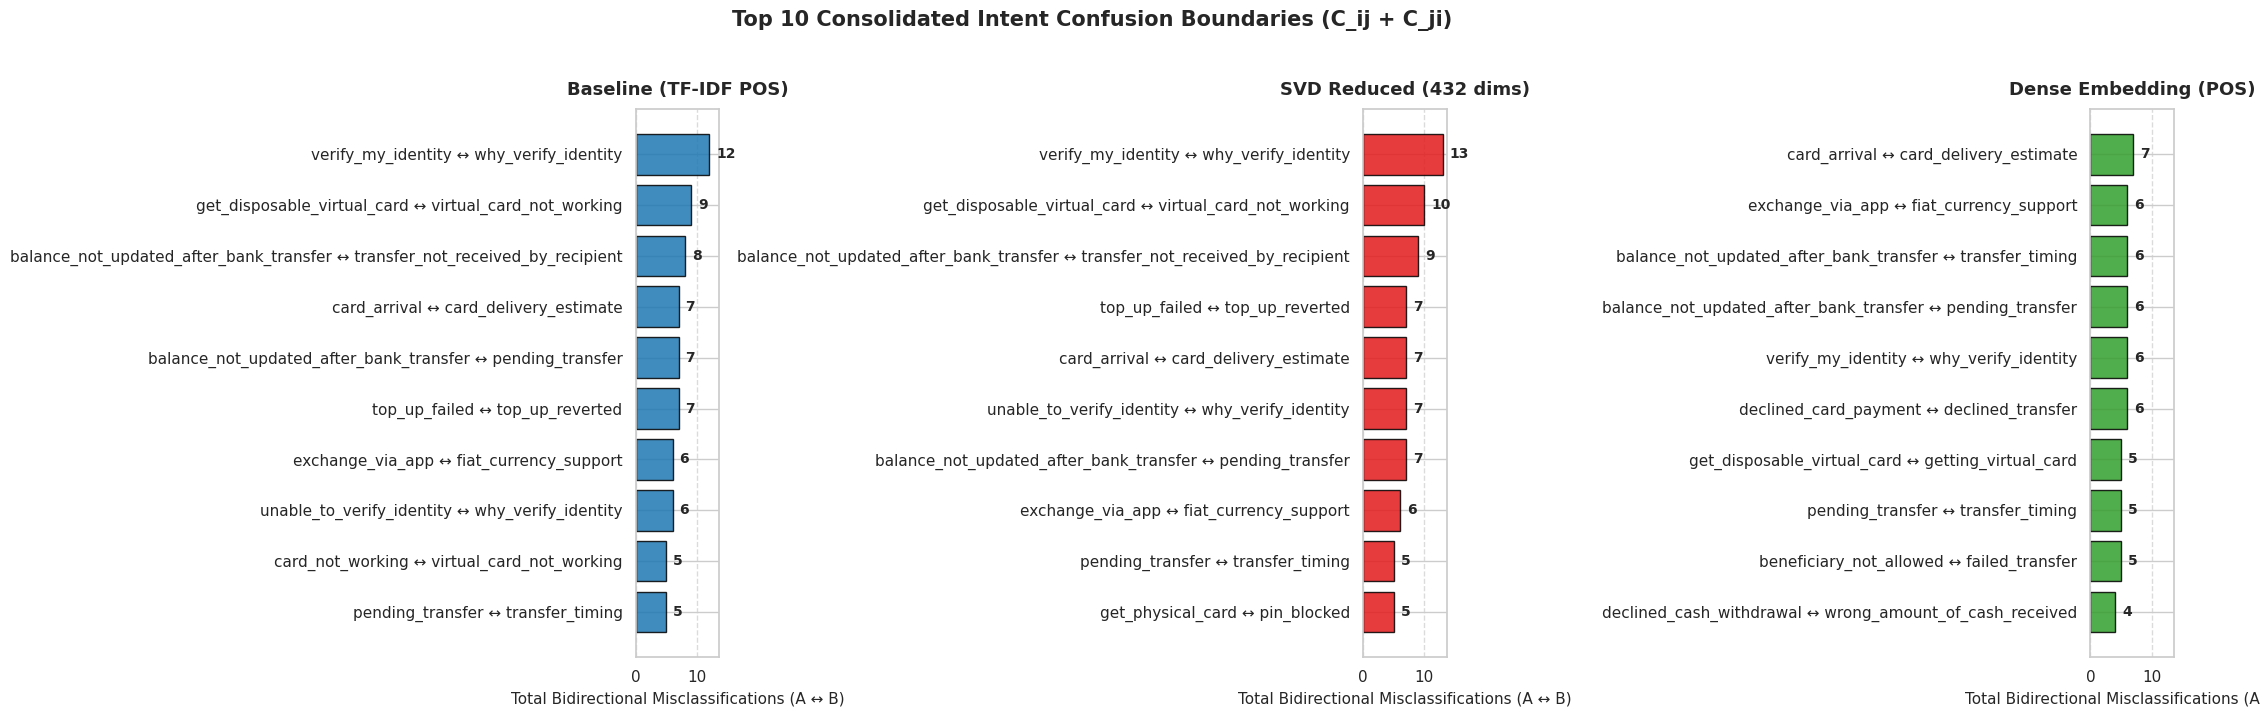


--- Consolidated Intent Boundary Analysis ---
1. Overlap (Baseline vs SVD): 9/10 identical top confusion boundaries
2. Overlap (Baseline vs Embedding): 5/10 identical top confusion boundaries
3. Weak boundaries introduced by SVD: {'get_physical_card ↔ pin_blocked'}
4. Weak boundaries clarified/resolved by Embedding: {'top_up_failed ↔ top_up_reverted', 'get_disposable_virtual_card ↔ virtual_card_not_working', 'balance_not_updated_after_bank_transfer ↔ transfer_not_received_by_recipient', 'unable_to_verify_identity ↔ why_verify_identity', 'card_not_working ↔ virtual_card_not_working'}


In [ ]:
## 5.1.2 Confusion Matrix Focus: Identifying Top Consolidated Confusion Pairs (Single-Fit SVD & Bidirectional A ↔ B)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sentence_transformers import SentenceTransformer

# ---------------------------------------------------------
# 1. Symmetrized & Consolidated Helper Function
# ---------------------------------------------------------
def get_top_confusion_pairs(y_true, y_pred, label_names, model_name, top_n=10):
    cm = confusion_matrix(y_true, y_pred)

    # 1. Zero out diagonal to exclude correct classifications
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    # 2. Symmetrize Matrix: S = C + C^T to consolidate bidirectional confusions (A -> B + B -> A)
    sym_cm = cm_no_diag + cm_no_diag.T

    # 3. Mask to strictly select Upper Triangle (i < j) to prevent double counting {i, j} and {j, i}
    triu_mask = np.triu(np.ones_like(sym_cm, dtype=bool), k=1)

    rows, cols = np.where(triu_mask)
    values = sym_cm[rows, cols]

    # Sort descending by consolidated error count
    top_indices = np.argsort(values)[-top_n:][::-1]

    records = []
    for idx in top_indices:
        r, c = rows[idx], cols[idx]
        total_err = sym_cm[r, c]
        fwd_err = cm_no_diag[r, c]  # True: r, Pred: c (A ➔ B)
        bwd_err = cm_no_diag[c, r]  # True: c, Pred: r (B ➔ A)

        records.append({
            'Model': model_name,
            'Intent A': label_names[r],
            'Intent B': label_names[c],
            'Error Pair': f"{label_names[r]} ↔ {label_names[c]}",
            'Total Error Count': total_err,
            'Forward (A➔B)': fwd_err,
            'Backward (B➔A)': bwd_err
        })
    return pd.DataFrame(records)

# ---------------------------------------------------------
# 2. Extract Labels & Target Vector
# ---------------------------------------------------------
## label_names = dataset['train'].features['label'].names
# 2. Extract label names directly from the DataFrame
label_map = train_df.set_index('label')['label_text'].drop_duplicates().sort_index().to_dict()
label_names = [label_map[i] for i in sorted(label_map.keys())]
y_train = train_df['label']
y_test = test_df['label']

print("--- Step 5.1: Consolidated Confusion Analysis (Optimized Single-Fit SVD) ---")

# ---------------------------------------------------------
# 3. Model A: Baseline (Full TF-IDF POS Tagging + Logistic Regression)
# ---------------------------------------------------------
print("1/3 Training Baseline Logistic Regression (Full TF-IDF POS)...")
clf_baseline = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_baseline.fit(X_train_pos, y_train)
y_pred_baseline = clf_baseline.predict(X_test_pos)

# ---------------------------------------------------------
# 4. Model B: SVD Reduced (Single-Fit SVD + Array Slicing for 90% Variance)
# ---------------------------------------------------------
print("2/3 Fitting Single SVD & Slicing to 90% Explained Variance...")
# Fit SVD once for up to 600 components
svd_full = TruncatedSVD(n_components=600, random_state=42)
X_tr_600 = svd_full.fit_transform(X_train_pos)
X_te_600 = svd_full.transform(X_test_pos)

# Determine component count for 90% cumulative explained variance
n_comp_90_pos = np.argmax(np.cumsum(svd_full.explained_variance_ratio_) >= 0.9) + 1

# Slice arrays directly without double fitting!
X_tr_pos_svd = X_tr_600[:, :n_comp_90_pos]
X_te_pos_svd = X_te_600[:, :n_comp_90_pos]

clf_svd = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_svd.fit(X_tr_pos_svd, y_train)
y_pred_svd = clf_svd.predict(X_te_pos_svd)
print(f"    Selected Dimensions: {n_comp_90_pos} components (Sliced from single SVD fit)")

# ---------------------------------------------------------
# 5. Model C: Dense Embedding (all-MiniLM-L6-v2 on POS + Logistic Regression)
# ---------------------------------------------------------
print("3/3 Generating Dense Embeddings for POS Text & Training Embedding Logistic Regression...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_tr_pos_emb = embedder.encode(train_df['smart_pos_text'].tolist(), show_progress_bar=False)
X_te_pos_emb = embedder.encode(test_df['smart_pos_text'].tolist(), show_progress_bar=False)

clf_emb = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf_emb.fit(X_tr_pos_emb, y_train)
y_pred_emb = clf_emb.predict(X_te_pos_emb)

# ---------------------------------------------------------
# 6. Extract Top 10 Consolidated Confusion Pairs
# ---------------------------------------------------------
df_err_base = get_top_confusion_pairs(y_test, y_pred_baseline, label_names, "Baseline (TF-IDF POS)")
df_err_svd  = get_top_confusion_pairs(y_test, y_pred_svd, label_names, f"SVD Reduced ({n_comp_90_pos} dims)")
df_err_emb  = get_top_confusion_pairs(y_test, y_pred_emb, label_names, "Dense Embedding (POS)")

df_top_errors_all = pd.concat([df_err_base, df_err_svd, df_err_emb], ignore_index=True)

# ---------------------------------------------------------
# 7. Print Detailed Comparison Tables
# ---------------------------------------------------------
print("\n================ TOP 10 CONSOLIDATED CONFUSION PAIRS (A ↔ B) ================")
models_list = ["Baseline (TF-IDF POS)", f"SVD Reduced ({n_comp_90_pos} dims)", "Dense Embedding (POS)"]
for model_name in models_list:
    print(f"\n--- {model_name} ---")
    sub = df_top_errors_all[df_top_errors_all['Model'] == model_name]
    print(sub[['Error Pair', 'Total Error Count', 'Forward (A➔B)', 'Backward (B➔A)']].to_string(index=False))

# ---------------------------------------------------------
# 8. Visual Comparison: Consolidated Error Counts
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True)
colors = ['#1f78b4', '#e31a1c', '#33a02c']

for idx, m_name in enumerate(models_list):
    ax = axes[idx]
    sub_data = df_top_errors_all[df_top_errors_all['Model'] == m_name].sort_values('Total Error Count', ascending=True)

    ax.barh(sub_data['Error Pair'], sub_data['Total Error Count'], color=colors[idx], alpha=0.85, edgecolor='black')
    ax.set_title(m_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Total Bidirectional Misclassifications (A ↔ B)", fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    for p in ax.patches:
        w = p.get_width()
        ax.annotate(f"{int(w)}", (w, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.suptitle("Top 10 Consolidated Intent Confusion Boundaries (C_ij + C_ji)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Pattern Continuity & SVD/Embedding Comparison
# ---------------------------------------------------------
pairs_base = set(df_err_base['Error Pair'])
pairs_svd  = set(df_err_svd['Error Pair'])
pairs_emb  = set(df_err_emb['Error Pair'])

print("\n--- Consolidated Intent Boundary Analysis ---")
print(f"1. Overlap (Baseline vs SVD): {len(pairs_base.intersection(pairs_svd))}/10 identical top confusion boundaries")
print(f"2. Overlap (Baseline vs Embedding): {len(pairs_base.intersection(pairs_emb))}/10 identical top confusion boundaries")
print(f"3. Weak boundaries introduced by SVD: {pairs_svd - pairs_base}")
print(f"4. Weak boundaries clarified/resolved by Embedding: {pairs_base - pairs_emb}")

## 5.2 ERROR INSPECTION & Confidence

In [ ]:
## 5.2 Qualitative Error Inspection: Failure Mechanism & Confidence Analysis

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Calculate Prediction Probabilities for Confidence Analysis
# ---------------------------------------------------------
print("--- Calculating Prediction Probabilities (Confidence Scores) ---")
probs_baseline = clf_baseline.predict_proba(X_test_pos)
probs_emb = clf_emb.predict_proba(X_te_pos_emb)

# ---------------------------------------------------------
# 2. Identify Top 3 Consolidated Confusion Pairs from Step 5.1
# ---------------------------------------------------------
top_3_pairs = df_err_base.head(3)

print("\nTop 3 Consolidated Confusion Pairs Selected for Inspection:")
for idx, row in top_3_pairs.iterrows():
    print(f"Pair {idx+1}: {row['Error Pair']} (Total Errors: {row['Total Error Count']})")

# ---------------------------------------------------------
# 3. Sampling & Inspection Pipeline
# ---------------------------------------------------------
inspection_results = []

for idx, pair_row in top_3_pairs.iterrows():
    intent_a = pair_row['Intent A']
    intent_b = pair_row['Intent B']

    idx_a = label_names.index(intent_a)
    idx_b = label_names.index(intent_b)

    # Filter test samples belonging to intent_a or intent_b where Baseline made a mistake
    is_true_pair = test_df['label'].isin([idx_a, idx_b])
    is_baseline_err = (y_pred_baseline != y_true) & is_true_pair

    # Filter rows where Baseline misclassified intent_a ➔ intent_b OR intent_b ➔ intent_a
    err_mask = is_baseline_err & (
        ((y_true == idx_a) & (y_pred_baseline == idx_b)) |
        ((y_true == idx_b) & (y_pred_baseline == idx_a))
    )

    err_indices = test_df[err_mask].index

    # If more than 5 errors exist, sort by Baseline confidence to get a mix of high-confidence & borderline errors
    if len(err_indices) > 5:
        # Get Baseline error confidence scores for these indices
        confidences = [probs_baseline[i, y_pred_baseline[i]] for i in err_indices]
        sorted_indices = [x for _, x in sorted(zip(confidences, err_indices), reverse=True)]

        # Pick top 3 highest confidence errors (Catastrophic) + 2 lowest confidence errors (Borderline)
        selected_indices = sorted_indices[:3] + sorted_indices[-2:]
    else:
        selected_indices = err_indices.tolist()

    for sample_idx in selected_indices:
        t_label = y_true.iloc[sample_idx]
        p_base_label = y_pred_baseline[sample_idx]
        p_emb_label = y_pred_emb[sample_idx]

        conf_base = probs_baseline[sample_idx, p_base_label]
        prob_base_true = probs_baseline[sample_idx, t_label]

        conf_emb = probs_emb[sample_idx, p_emb_label]
        prob_emb_true = probs_emb[sample_idx, t_label]

        # Categorize Error Severity (Baseline)
        err_type = "Catastrophic (High Conf)" if conf_base >= 0.70 else "Borderline (Low Conf)"

        # Check if Embedding fixed the error
        emb_status = "FIXED BY EMBEDDING" if p_emb_label == t_label else "STILL MISCLASSIFIED"

        inspection_results.append({
            'Pair': f"{intent_a} ↔ {intent_b}",
            'Sample ID': sample_idx,
            'Original Text': test_df.loc[sample_idx, 'text'],
            'Clean POS Text': test_df.loc[sample_idx, 'smart_pos_text'],
            'True Label': label_names[t_label],
            'Baseline Pred': label_names[p_base_label],
            'Baseline Conf': f"{conf_base:.1%}",
            'Embedding Pred': label_names[p_emb_label],
            'Embedding Conf': f"{conf_emb:.1%}",
            'Embedding Impact': emb_status,
            'Error Taxonomy': err_type
        })

df_inspection = pd.DataFrame(inspection_results)

# ---------------------------------------------------------
# 4. Display Formatted Qualitative Inspection Table
# ---------------------------------------------------------
print("\n================ 5.2 QUALITATIVE ERROR INSPECTION TABLE ================")
for pair_name in df_inspection['Pair'].unique():
    print(f"\n==========================================================================")
    print(f"CONFUSION PAIR: {pair_name}")
    print(f"==========================================================================")

    sub = df_inspection[df_inspection['Pair'] == pair_name]
    for row_i, r in sub.iterrows():
        print(f"\n[Sample ID: {r['Sample ID']}] | Type: {r['Error Taxonomy']} | Impact: {r['Embedding Impact']}")
        print(f"Text          : \"{r['Original Text']}\"")
        print(f"POS Clean Text: \"{r['Clean POS Text']}\"")
        print(f"True Intent   : {r['True Label']}")
        print(f"Baseline Pred : {r['Baseline Pred']} (Conf: {r['Baseline Conf']})")
        print(f"Embedding Pred: {r['Embedding Pred']} (Conf: {r['Embedding Conf']})")
        print("-" * 75)

--- Calculating Prediction Probabilities (Confidence Scores) ---

Top 3 Consolidated Confusion Pairs Selected for Inspection:
Pair 1: verify_my_identity ↔ why_verify_identity (Total Errors: 12)
Pair 2: get_disposable_virtual_card ↔ virtual_card_not_working (Total Errors: 9)
Pair 3: balance_not_updated_after_bank_transfer ↔ transfer_not_received_by_recipient (Total Errors: 8)


NameError: name 'y_true' is not defined

## 5.3 Feature Importance & Anchor Words


In [ ]:
## 5.3 Feature Importance & Anchor Words Analysis Across Confusion Pairs (FIXED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Advanced Anchor Words Extraction Function
# ---------------------------------------------------------
def get_problematic_anchor_words(clf, vectorizer, label_names, intent_a, intent_b, top_n=10):
    """
    מזהה מילים בעייתיות (Anchor Words) המקבלות משקל חיובי גבוה בשתי המחלקות במקביל,
    מה שמקטין את מרווח ה-Log-Odds ומטשטש את גבול ההחלטה הליניארי.
    """
    idx_a = list(label_names).index(intent_a)
    idx_b = list(label_names).index(intent_b)

    weights_a = clf.coef_[idx_a]
    weights_b = clf.coef_[idx_b]
    feature_names = vectorizer.get_feature_names_out()

    # Filter only features where BOTH weights are strictly positive (attract both classes)
    positive_mask = (weights_a > 0) & (weights_b > 0)

    pos_indices = np.where(positive_mask)[0]

    if len(pos_indices) == 0:
        return pd.DataFrame()

    records = []
    for idx in pos_indices:
        w_a = weights_a[idx]
        w_b = weights_b[idx]

        # Calculate Geometric Mean for joint strength & absolute difference for ambiguity
        joint_strength = np.sqrt(w_a * w_b)
        weight_diff = abs(w_a - w_b)

        # Anchor Score: Rewards high joint weight and low weight difference (ambiguity)
        anchor_score = joint_strength / (1.0 + weight_diff)

        records.append({
            'Word': feature_names[idx],
            f'Weight ({intent_a})': round(w_a, 4),
            f'Weight ({intent_b})': round(w_b, 4),
            'Combined Weight Sum': round(w_a + w_b, 4),
            'Weight Difference': round(weight_diff, 4),
            'Anchor Score': round(anchor_score, 4)
        })

    df_anchors = pd.DataFrame(records)

    # Sort by Anchor Score descending
    if not df_anchors.empty:
        df_anchors = df_anchors.sort_values(by='Anchor Score', ascending=False).head(top_n)

    return df_anchors

# ---------------------------------------------------------
# 2. Iterate Over Top 3 Consolidated Confusion Pairs from Step 5.1/5.2
# ---------------------------------------------------------
print("--- Step 5.3: Feature Importance & Shared Anchor Words Extraction ---")

# We use the vectorizer `tfidf_pos` and classifier `clf_baseline` from step 5.1
anchor_results_dict = {}

for idx, pair_row in top_3_pairs.iterrows():
    intent_a = pair_row['Intent A']
    intent_b = pair_row['Intent B']
    pair_name = f"{intent_a} ↔ {intent_b}"

    df_anchors = get_problematic_anchor_words(
        clf=clf_baseline,
        vectorizer=tfidf_pos,
        label_names=label_names,
        intent_a=intent_a,
        intent_b=intent_b,
        top_n=8
    )

    anchor_results_dict[pair_name] = df_anchors

    print(f"\n==========================================================================")
    print(f"TOP ANCHOR WORDS FOR CONFUSION PAIR: {pair_name}")
    print(f"==========================================================================")
    if not df_anchors.empty:
        print(df_anchors[['Word', f'Weight ({intent_a})', f'Weight ({intent_b})', 'Combined Weight Sum', 'Anchor Score']].to_string(index=False))
    else:
        print("No strongly overlapping positive anchor words found for this pair.")

# ---------------------------------------------------------
# 3. Visualization: Side-by-Side Anchor Feature Weights
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, (pair_name, df_anchors) in enumerate(anchor_results_dict.items()):
    ax = axes[idx]
    if df_anchors.empty:
        ax.set_title(f"No Shared Anchors\n{pair_name}")
        continue

    intent_a = df_anchors.columns[1].replace('Weight (', '').replace(')', '')
    intent_b = df_anchors.columns[2].replace('Weight (', '').replace(')', '')

    # Melt dataframe for paired horizontal bar plot (FIXED: value_name parameter)
    df_plot = df_anchors.melt(
        id_vars=['Word'],
        value_vars=[f'Weight ({intent_a})', f'Weight ({intent_b})'],
        var_name='Intent Class',
        value_name='Coefficient Weight'
    )

    # Clean up intent column names for legend
    df_plot['Intent Class'] = df_plot['Intent Class'].str.extract(r'\((.*)\)')

    sns.barplot(
        data=df_plot,
        y='Word',
        x='Coefficient Weight',
        hue='Intent Class',
        palette=['#1f78b4', '#ff7f00'],
        ax=ax
    )

    ax.set_title(f"Anchor Coefficients: {pair_name}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Logistic Regression Coefficient (Positive Attraction)", fontsize=10)
    ax.set_ylabel("Anchor Word Token", fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.legend(title="Intent Class", loc="lower right", fontsize=9)

plt.suptitle("Feature Importance: Identification of Shared Domain Anchor Words Obscuring Decision Boundaries", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5.4 Hierarchical Intent Analysis

### 5.4.1 viewing the missmatching

In [ ]:
# ==============================================================================
# שלב 5.4.1: ניתוח זוגות וקבוצות בלבול (Dense Embedding Focus)
# ==============================================================================

print("=== שלב 5.4.1: ניתוח זוגות וקבוצות בלבול (Dense Embedding) ===")

# 1. חישוב מטריצת הבלבול (Confusion Matrix) של מודל האמבדינג
cm_emb = confusion_matrix(y_test, y_pred_emb)

# איפוס האלכסון הראשי להתמקד בטעויות סיווג
cm_no_diag = cm_emb.copy()
np.fill_diagonal(cm_no_diag, 0)

# סימטריזציה להערכת עננות הבלבול הדו-כיווניות (A -> B + B -> A)
sym_cm = cm_no_diag + cm_no_diag.T

# בחירת המשולש העליון (i < j) למניעת כפילויות
triu_mask = np.triu(np.ones_like(sym_cm, dtype=bool), k=1)
rows, cols = np.where(triu_mask & (sym_cm > 0))

# 2. יצירת טבלת כל זוגות הבלבול המרכזיים (Candidate Confusion Pairs)
values = sym_cm[rows, cols]
top_20_indices = np.argsort(values)[-20:][::-1]

pairs_data = []
for idx in top_20_indices:
    r, c = rows[idx], cols[idx]
    tot_err = sym_cm[r, c]
    fwd_err = cm_no_diag[r, c]  # True: A, Pred: B
    bwd_err = cm_no_diag[c, r]  # True: B, Pred: A

    diff = abs(fwd_err - bwd_err)
    if diff <= 1:
        sym_type = "Symmetric (A <-> B)"
    elif fwd_err > bwd_err:
        sym_type = f"Asymmetric (Dominant: {label_names[r]} -> {label_names[c]})"
    else:
        sym_type = f"Asymmetric (Dominant: {label_names[c]} -> {label_names[r]})"

    pairs_data.append({
        'Intent A': label_names[r],
        'Intent B': label_names[c],
        'Error Pair': f"{label_names[r]} <-> {label_names[c]}",
        'Total Error Count': tot_err,
        'Forward (A->B)': fwd_err,
        'Backward (B->A)': bwd_err,
        'Symmetry Breakdown': sym_type
    })

df_top20_confusions = pd.DataFrame(pairs_data)

print("\n--- Top 20 Candidate Intent Confusion Pairs (Data Summary) ---")
print(df_top20_confusions[['Error Pair', 'Total Error Count', 'Forward (A->B)', 'Backward (B->A)', 'Symmetry Breakdown']].to_string(index=False))

# 3. חילוץ אשכולות בלבול מרובי-כוונות (Connected Components)
G = nx.Graph()
for r, c in zip(rows, cols):
    weight = sym_cm[r, c]
    if weight >= 2:  # סף בלבול מינימלי
        G.add_edge(label_names[r], label_names[c], weight=weight)

connected_components = [list(c) for c in nx.connected_components(G) if len(c) >= 3]

print("\n==========================================================================")
print(f"IDENTIFIED MULTI-WAY CONFUSION CLUSTERS (>=3 Intents): {len(connected_components)} Clusters")
print("==========================================================================")
for grp_idx, group in enumerate(connected_components, 1):
    print(f"\nCluster {grp_idx} ({len(group)} Member Intents):")
    for item in group:
        print(f"  - {item}")

# ------------------------------------------------------------------------------
# תצוגת אפשרויות ויזואליזציה לבחירתך (תוכל להריץ את האופציה המועדפת)
# ------------------------------------------------------------------------------

# --- אופציה א': תרשים דירוג אופקי (Horizontal Ranking Bar Chart) ---
SHOW_OPTION_A = True
if SHOW_OPTION_A:
    plt.figure(figsize=(12, 7))
    df_plot = df_top20_confusions.sort_values('Total Error Count', ascending=True)
    plt.barh(df_plot['Error Pair'], df_plot['Total Error Count'], color='#33a02c', edgecolor='black', alpha=0.85)
    for index, value in enumerate(df_plot['Total Error Count']):
        plt.text(value + 0.1, index, str(value), va='center', fontweight='bold', fontsize=10)
    plt.xlabel('Total Bidirectional Misclassifications (A <-> B)', fontsize=11)
    plt.title('Option A: Top 20 Intent Confusion Boundaries (Ranking)', fontsize=13, fontweight='bold', pad=15)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- אופציה ב': גרף רשת אשכולות (Network Graph of Semantic Clusters) ---
SHOW_OPTION_B = True
if SHOW_OPTION_B:
    plt.figure(figsize=(13, 9))
    pos = nx.spring_layout(G, k=0.4, seed=42)
    weights = [G[u][v]['weight'] * 1.2 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=600, node_color='#1f78b4', alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='crimson', alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

    plt.title("Option B: Network Graph of Intent Confusion Clusters (Topology)", fontsize=13, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- אופציה ג': מפת חום מרוכזת (Sub-Matrix Heatmap for Top Confused Intents) ---
SHOW_OPTION_C = True
if SHOW_OPTION_C:
    top_intents_unique = list(set(df_top20_confusions['Intent A']).union(set(df_top20_confusions['Intent B'])))
    top_indices_unique = [label_names.index(name) for name in top_intents_unique]

    sub_cm = cm_no_diag[np.ix_(top_indices_unique, top_indices_unique)]

    plt.figure(figsize=(11, 9))
    plt.imshow(sub_cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(label='Misclassification Count')
    plt.xticks(range(len(top_intents_unique)), top_intents_unique, rotation=90, fontsize=8)
    plt.yticks(range(len(top_intents_unique)), top_intents_unique, fontsize=8)
    plt.title("Option C: Focused Sub-Matrix Heatmap of Key Confused Intents", fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()